<a target="_blank" href="https://colab.research.google.com/github/mrdbourke/simple-local-rag/blob/main/00-simple-local-rag.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Building a local RAG pipeline in Python

This notebook builds a RAG (Retrieval Augmented Generation) pipeline from scratch that runs on a local GPU.

We'll open a PDF, ask questions about it, and have them answered by a Large Language Model (LLM).

Frameworks like [LlamaIndex](https://www.llamaindex.ai/) and [LangChain](https://www.langchain.com/) provide similar workflows, but building from scratch lets you inspect and customize every part.

## What is RAG?

RAG stands for Retrieval Augmented Generation, introduced in the paper [*Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks*](https://arxiv.org/abs/2005.11401).

Each step breaks down to:

* **Retrieval** - Find relevant information from a source given a query (e.g. fetching Wikipedia passages for a question).
* **Augmented** - Use the retrieved information to modify the input to a generative model (e.g. an LLM).
* **Generation** - Produce an output from that input, such as an LLM generating text from a prompt.

## Why RAG?

RAG improves the outputs of LLMs in two main ways:

1. **Reduces hallucinations** - LLMs can generate text that looks correct but isn't. Grounding generations in retrieved sources produces more factual answers, and gives you citations you can verify.
2. **Works with custom data** - Base LLMs are trained on internet-scale text but lack specific knowledge. RAG plugs in domain-specific data (medical info, company docs) without retraining the model.

The authors of the original RAG paper noted these benefits:

> This work offers several positive societal benefits over previous work: the fact that it is more
strongly grounded in real factual knowledge (in this case Wikipedia) makes it "hallucinate" less
with generations that are more factual, and offers more control and interpretability. RAG could be
employed in a wide variety of scenarios with direct benefit to society, for example by endowing it
with a medical index and asking it open-domain questions on that topic, or by helping people be more
effective at their jobs.

RAG is also often quicker to implement than fine-tuning an LLM on specific data.



## What kind of problems can RAG be used for?

RAG helps anywhere an LLM may not have specific information in its training data (e.g. anything not publicly accessible on the internet).

Common use cases:
* **Customer support Q&A** - Treat your existing support docs as the source. When a customer asks a question, retrieve relevant snippets and have an LLM craft an answer. Klarna [uses a system like this](https://www.klarna.com/international/press/klarna-ai-assistant-handles-two-thirds-of-customer-service-chats-in-its-first-month/) to save $40M per year on support costs.
* **Email chain analysis** - For long email threads (e.g. an insurance company's correspondence with customers), retrieve relevant passages and have an LLM produce structured outputs like claim summaries.
* **Internal documentation chat** - Index your company's docs so employees can ask questions and get answers, with linked references for follow-up.
* **Textbook Q&A** - Get answers from a large textbook along with references to learn more.

The common theme: retrieve relevant resources, then present them in an understandable way using an LLM.

From this angle, you can consider an LLM a calculator for words.


## Why local?

Privacy, speed, cost.

Running locally uses your own hardware:

* **Privacy** - Sensitive data never has to leave your machine.
* **Speed** - No API queues or downtime; if your hardware is on, the pipeline can run.
* **Cost** - Heavier upfront cost but little to no per-query cost afterward.

LLM APIs may still outperform open-source models on general tasks, but smaller focused open-source models are increasingly competitive.


## Key terms

| Term | Description |
| ----- | ----- |
| **Token** | A sub-word piece of text. For example, "hello, world!" could be split into ["hello", ",", "world", "!"]. A token can be a whole word,<br> part of a word, or a group of punctuation characters. 1 token ~= 4 characters in English, 100 tokens ~= 75 words.<br> Text gets broken into tokens before being passed to an LLM. |
| **Embedding** | A learned numerical representation of a piece of data. For example, a sentence could be represented by a vector with<br> 768 values. Pieces of text with similar meaning ideally have similar values. |
| **Embedding model** | A model that takes input data and outputs a numerical representation. A text embedding model may take in 512<br> tokens of text and turn it into a vector of size 1024. An embedding model is typically different from an LLM. |
| **Similarity search / vector search** | Finds vectors that are close together in high-dimensional space. Similar pieces of text passed through an embedding model<br> should have a high similarity score, while text on different topics will score lower. Common measures are dot product and cosine similarity. |
| **Large Language Model (LLM)** | A model trained to numerically represent the patterns in text. A generative LLM continues a sequence given one.<br> For example, given "hello, world!", a generative LLM may produce "we're going to build a RAG pipeline today!".<br> The generation depends heavily on the training data and prompt. |
| **LLM context window** | The number of tokens an LLM can accept as input. Modern proprietary LLMs commonly support 128k tokens or more,<br> while open-source models range from around 8k tokens up to 1M+ depending on the model. A larger context window lets an LLM<br> accept more relevant information; in a RAG pipeline, this means more retrieved passages can be used to aid generation. |
| **Prompt** | The input to a generative LLM. "[Prompt engineering](https://en.wikipedia.org/wiki/Prompt_engineering)" is the practice of structuring a text-based<br> (or sometimes image-based) input so the generated output is ideal. This works because of an LLM's capacity for in-context<br> learning: it uses its representation of language to break down the prompt and recognize a suitable output<br> (note: LLM outputs are probabilistic, so terms like "may output" are used). |




 ## What we're going to build

We'll build a RAG pipeline that lets us chat with an open source world history textbook(https://assets.openstax.org/oscms-prodcms/media/documents/World_History_Volume_2-WEB.pdf) about 700 pages long.

We'll write code to:
1. Open a PDF document (you can swap in almost any PDF).
2. Format the text for an embedding model (text splitting / chunking).
3. Embed each chunk into a numerical vector and store the vectors for later.
4. Build a retrieval system that uses vector search to find relevant chunks given a query.
5. Create a prompt that incorporates the retrieved passages.
6. Generate an answer to the query based on those passages.

These steps split into two major sections:
1. Document preprocessing and embedding creation (steps 1-3).
2. Search and answer (steps 4-6).

That's the structure we'll follow.

It's similar to the workflow outlined on the NVIDIA blog, which [details a local RAG pipeline](https://developer.nvidia.com/blog/rag-101-demystifying-retrieval-augmented-generation-pipelines/).

<img src="https://github.com/mrdbourke/simple-local-rag/blob/main/images/simple-local-rag-workflow-flowchart.png?raw=true" alt="flowchart of a local RAG workflow" />

## Requirements and setup

* Environment setup (see [setup details on GitHub](https://github.com/mrdbourke/simple-local-rag/?tab=readme-ov-file#setup)).
* Data source (for example, a PDF).
* Internet connection (to download the models, but once you have them, it'll run offline).

In [1]:
# OFFLINE MODE: this notebook assumes you've already run `python warmup.py` (which downloads the
# LLM, embedding model, and PDF) and `pip install -r requirements.txt`. We force Hugging Face into
# offline mode here so that any model load goes straight to your local cache and never hits the
# network. If a model is missing from cache, you'll get a clear error rather than a silent slow download.
import os
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

## 1. Document/Text Processing and Embedding Creation

Ingredients:
* PDF document of choice.
* Embedding model of choice.

Steps:
1. Import PDF document.
2. Process text for embedding (e.g. split into chunks of sentences).
3. Embed text chunks with embedding model.
4. Save embeddings to file for later use (embeddings will store on file for many years or until you lose your hard drive).

### Import PDF Document

This will work with many other kinds of documents.

However, we'll start with PDF since many people have PDFs.

But just keep in mind, text files, email chains, support documentation, articles and more can also work.

There are several libraries to open PDFs with Python but I found that [PyMuPDF](https://github.com/pymupdf/pymupdf) works quite well in many cases.

First we'll download the PDF if it doesn't exist.

In [2]:
# `requests` is already installed via requirements.txt. Skipping pip install.

In [3]:
# Download PDF file
import os
import requests

# Get PDF document
pdf_path = "world-history-text.pdf"

# Download PDF if it doesn't already exist
if not os.path.exists(pdf_path):
  print("File doesn't exist, downloading...")

  # The URL of the PDF you want to download
  url = "https://assets.openstax.org/oscms-prodcms/media/documents/World_History_Volume_2-WEB.pdf"

  # The local filename to save the downloaded file
  filename = pdf_path

  # Send a GET request to the URL
  response = requests.get(url)

  # Check if the request was successful
  if response.status_code == 200:
      # Open a file in binary write mode and save the content to it
      with open(filename, "wb") as file:
          file.write(response.content)
      print(f"The file has been downloaded and saved as {filename}")
  else:
      print(f"Failed to download the file. Status code: {response.status_code}")
else:
  print(f"File {pdf_path} exists.")

File doesn't exist, downloading...
The file has been downloaded and saved as world-history-text.pdf


PDF acquired!

We can import the pages of our PDF to text by first defining the PDF path and then opening and reading it with PyMuPDF (`import fitz`).

We'll write a small helper function to preprocess the text as it gets read. Note that not all text will be read in the same so keep this in mind for when you prepare your text.

We'll save each page to a dictionary and then append that dictionary to a list for ease of use later.

In [4]:
# Requires !pip install PyMuPDF, see: https://github.com/pymupdf/pymupdf
import fitz # (pymupdf, found this is better than pypdf for our use case, note: licence is AGPL-3.0, keep that in mind if you want to use any code commercially)

"""
Design Choice : 
Layout-aware / ML-based converters (Docling, Marker, MarkItDown, Unstructured, LlamaParse) 
run models to recover document structure — headings, sections, tables, figures, reading order — 
and emit clean Markdown or JSON. Use these when retrieval quality matters and your sources have 
real structure (textbooks, papers, reports), since you can then chunk on semantic boundaries instead of arbitrary character windows.
"""
from tqdm.auto import tqdm # for progress bars, requires !pip install tqdm

def clean_page_text(text: str) -> str:
    """Performs minor formatting on text."""
    cleaned_text = text.replace("\n", " ").strip() # note: this might be different for each doc (best to experiment)

    # Other potential text formatting functions can go here
    return cleaned_text

# Open PDF and get lines/pages
# Note: this only focuses on text, rather than images/figures etc
def read_pdf(pdf_path: str) -> list[dict]:
    """
    Opens a PDF file, reads its text content page by page, and collects statistics.

    Parameters:
        pdf_path (str): The file path to the PDF document to be opened and read.

    Returns:
        list[dict]: A list of dictionaries, each containing the page number
        (adjusted), character count, word count, sentence count, token count, and the extracted text
        for each page.
    """
    doc = fitz.open(pdf_path)  # open a document
    pages = []
    for page_number, page in tqdm(enumerate(doc)):  # iterate the document pages
        text = page.get_text()  # get plain text encoded as UTF-8
        text = clean_page_text(text)
        pages.append({"page_number": page_number - 19,  # adjust page numbers since our PDF starts on page 42
                                "page_word_count": len(text.split(" ")),
                                "page_sentence_count": len(text.split(". ")),
                                "page_token_count": len(text) / 4,  # 1 token = ~4 chars, see: https://help.openai.com/en/articles/4936856-what-are-tokens-and-how-to-count-them
                                "text": text})
    return pages

pages = read_pdf(pdf_path=pdf_path)
pages[:2]

/Users/ismichel/miniconda3/envs/rag/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
723it [00:10, 70.86it/s]


[{'page_number': -19,
  'page_word_count': 6,
  'page_sentence_count': 1,
  'page_token_count': 8.25,
  'text': 'ory Hist- World Volume2 from 1400'},
 {'page_number': -18,
  'page_word_count': 1,
  'page_sentence_count': 1,
  'page_token_count': 0.0,
  'text': ''}]

Now let's get a random sample of the pages.

In [5]:
import random

random.sample(pages, k=3)

[{'page_number': 330,
  'page_word_count': 441,
  'page_sentence_count': 22,
  'page_token_count': 684.0,
  'text': 'materials than to pursuing widespread industrialization. In each nation, a unique set of circumstances  influenced the path taken.  India  India’s industrial endeavors were greatly affected by its relationship with Britain, which had begun trading in  India in the 1600s. The Seven Years’ War and the subsequent Treaty of Paris, signed in 1763, effectively  brought French power in India to an end, paving the way for Britain’s eventual control of the subcontinent. At  this time, India possessed characteristics that seemed to make it an ideal candidate for industrialization. It had  large merchant and artisan classes, which produced beautiful textiles highly valued in sixteenth- and  seventeenth-century England. India was, in fact, the largest exporter of cotton cloth in the world by the middle  of the eighteenth century. It was also wealthy, and the country’s Mughal rulers 

### Get some stats on the text

Let's perform a rough exploratory data analysis (EDA) to get an idea of the size of the texts (e.g. character counts, word counts etc) we're working with.

The different sizes of texts will be a good indicator into how we should split our texts.

Many embedding models have limits on the size of texts they can ingest, for example, the [`sentence-transformers`](https://www.sbert.net/docs/pretrained_models.html) model [`mxbai-embed-large-v1`](https://huggingface.co/mixedbread-ai/mxbai-embed-large-v1) we'll use has an input size of 512 tokens.

This means that the model has been trained to ingest and turn into embeddings texts with up to 512 tokens (1 token ~= 4 characters ~= 0.75 words).

Texts over 512 tokens encoded by this model will be automatically truncated to 512 tokens, potentially losing some information.

We'll discuss this more in the embedding section.

For now, let's turn our list of dictionaries into a DataFrame and explore it.

In [6]:
import pandas as pd

df = pd.DataFrame(pages)
df.head()

,page_number,page_word_count,page_sentence_count,page_token_count,text
0,-19,6,1,8.25,ory Hist- World Volume2 from 1400
1,-18,1,1,0.00,
2,-17,38,2,59.25,"World History, Volume 2: from 1400 SENIOR CO..."
3,-16,409,13,616.00,OpenStax Rice University 6100 Main Street MS...
4,-15,324,17,508.25,"OPENSTAX OpenStax provides free, peer-reviewe..."


In [7]:
# Get stats
df.describe().round(2)

,page_number,page_word_count,page_sentence_count,page_token_count
count,723.00,723.00,723.00,723.00
mean,342.00,493.30,21.73,715.77
std,208.86,201.72,11.81,292.21
min,-19.00,1.00,1.00,0.00
25%,161.50,358.50,14.00,527.12
50%,342.00,471.00,20.00,689.75
75%,522.50,673.50,29.00,969.12
max,703.00,950.00,59.00,1268.00


Okay, looks like our average token count per page is 287.

For this particular use case, it means we could embed an average whole page with the `mxbai-embed-large-v1` model (this model has an input capacity of 512 tokens).

### Further text processing (splitting pages into sentences)

The ideal way of processing text before embedding it is still an active area of research.

A simple method I've found helpful is to break the text into chunks of sentences.

As in, chunk a page of text into groups of 5, 7, 10 or more sentences (these values are not set in stone and can be explored).

But we want to follow the workflow of:

`Ingest text -> split it into groups/chunks -> embed the groups/chunks -> use the embeddings`

Some options for splitting text into sentences:

1. Split into sentences with simple rules (e.g. split on ". " with `text = text.split(". ")`, like we did above).
2. Split into sentences with a natural language processing (NLP) library such as [spaCy](https://spacy.io/) or [nltk](https://www.nltk.org/).

Why split into sentences?

* Easier to handle than larger pages of text (especially if pages are densely filled with text).
* Can get specific and find out which group of sentences were used to help within a RAG pipeline.

> **Resource:** See [spaCy install instructions](https://spacy.io/usage).

Let's use spaCy to break our text into sentences since it's likely a bit more robust than just using `text.split(". ")`.

In [8]:
# `spacy` is already installed via requirements.txt. Skipping pip install.

In [9]:
from spacy.lang.en import English # see https://spacy.io/usage for install instructions

"""
A processing pipeline is an ordered 
sequence of components that each take 
some input, transform it, and pass the 
result to the next component — so raw data 
flows through stage after stage until it 
emerges in its final, fully-processed form.
"""

nlp = English()

# Add a sentencizer pipeline, see https://spacy.io/api/sentencizer/
nlp.add_pipe("sentencizer") # sentence splitter pipeline

# Create a document instance as an example
doc = nlp("This is my first sentence. This is my second sentence.")
assert len(list(doc.sents)) == 2

# Access the sentences of the document
list(doc.sents)

[This is my first sentence., This is my second sentence.]

We don't necessarily need to use spaCy, however, it's an open-source library designed to do NLP tasks like this at scale.

So let's run our small sentencizing pipeline on our pages of text.

In [10]:
for item in tqdm(pages):
    item["sentences"] = list(nlp(item["text"]).sents)

    # Make sure all sentences are strings
    item["sentences"] = [str(sentence) for sentence in item["sentences"]]

    # Count the sentences
    item["page_sentence_count_spacy"] = len(item["sentences"])

100%|██████████| 723/723 [00:03<00:00, 194.15it/s]


In [11]:
# Inspect an example
random.sample(pages, k=1)

[{'page_number': 158,
  'page_word_count': 357,
  'page_sentence_count': 16,
  'page_token_count': 529.25,
  'text': 'Portuguese Exploration  In the late 1400s, both Portugal and Spain were emerging from centuries of rule by North African Muslim  states. Portugal had become an independent country by the twelfth century (Figure 5.8). At the beginning of  the fifteenth century, it was a small country with poor soil. However, it did have one advantage—a geographical  location that lent itself to exploration, specifically down the African coastline and across the Atlantic. Portugal  also had plenty of coves and natural harbors suited for shipping, and speedy crosswinds and currents that  gave it a shipping superhighway of sorts between northern and southern Europe. Various nearby islands such  as the Azores also teemed with untapped fishing potential.  FIGURE 5.8 Afonso Henriques. In this detail from a page in an illuminated manuscript of the 1530s, Afonso  Henriques declares himself king 

Wonderful!

Now let's turn out list of dictionaries into a DataFrame and get some stats.

In [12]:
df = pd.DataFrame(pages)
df.describe().round(2)

,page_number,page_word_count,page_sentence_count,page_token_count,page_sentence_count_spacy
count,723.00,723.00,723.00,723.00,723.00
mean,342.00,493.30,21.73,715.77,20.80
std,208.86,201.72,11.81,292.21,10.67
min,-19.00,1.00,1.00,0.00,0.00
25%,161.50,358.50,14.00,527.12,14.00
50%,342.00,471.00,20.00,689.75,21.00
75%,522.50,673.50,29.00,969.12,28.00
max,703.00,950.00,59.00,1268.00,63.00


For our set of text, it looks like our raw sentence count (e.g. splitting on `". "`) is quite close to what spaCy came up with.

Now we've got our text split into sentences, how about we gorup those sentences?

### Chunking our sentences together

Let's take a step to break down our list of sentences/text into smaller chunks.

As you might've guessed, this process is referred to as **chunking**.

Why do we do this?

1. Easier to manage similar sized chunks of text.
2. Don't overload the embedding model's capacity for tokens (e.g. if an embedding model has a capacity of 256 tokens, there could be information loss if you try to embed a sequence of 300+ tokens).
3. Our LLM context window (the amount of tokens an LLM can take in) may be limited and requires compute power so we want to make sure we're using it as well as possible.

Something to note is that there are many different ways emerging for creating chunks of information/text.

For now, we're going to keep it simple and break our pages of sentences into groups of 10 (this number is arbitrary and can be changed — feel free to drop it to 7 or 8 if you want to stay comfortably under our embedding model's 256-token cap).

On average each of our pages has 10 sentences.

And an average total of 287 tokens per page.

So our groups of 10 sentences will also be ~287 tokens long.

This gives us plenty of room for the text to be embedded by our `mxbai-embed-large-v1` model (it has a capacity of 512 tokens).

To split our groups of sentences into chunks of 10 or less, let's create a function which accepts a list as input and recursively breaks into down into sublists of a specified size.

In [13]:
# Define split size to turn groups of sentences into chunks
num_sentence_chunk_size = 10

# Create a function that recursively splits a list into desired sizes
def split_list(input_list: list,
               slice_size: int) -> list[list[str]]:
    """
    Splits the input_list into sublists of size slice_size (or as close as possible).

    For example, a list of 17 sentences would be split into two lists of [[10], [7]]
    """
    return [input_list[i:i + slice_size] for i in range(0, len(input_list), slice_size)]

# Loop through pages and texts and split sentences into chunks
for item in tqdm(pages):
    item["sentence_chunks"] = split_list(input_list=item["sentences"],
                                         slice_size=num_sentence_chunk_size)
    item["num_chunks"] = len(item["sentence_chunks"])

100%|██████████| 723/723 [00:00<00:00, 203018.13it/s]


In [14]:
# Sample an example from the group (note: many samples have only 1 chunk as they have <=10 sentences total)
random.sample(pages, k=1)

[{'page_number': 478,
  'page_word_count': 670,
  'page_sentence_count': 28,
  'page_token_count': 994.0,
  'text': 'In 1927, Stalin expelled Trotsky from the Communist Party. In 1929, Trotsky was forced into exile. He was  assassinated by a Soviet agent in Mexico in 1940. By the end of the 1920s, although the new Soviet government  did seek to fulfill some of the promises Bolshevism had held out, the collective approach of the early years of  the decade had devolved to one-man rule.  The First Five-Year Plan  Stalin’s domestic agenda was codified in the form of Five-Year Plans outlining economic achievements the  Soviet Union was to have made by each plan’s conclusion. The timeline was ambitious, if not impossible. Yet  officials tried to achieve the goals; they risked losing their jobs or even their lives for not meeting production  quotas.  The first Five-Year Plan was designed to rapidly industrialize the Soviet Union. Stalin abandoned his earlier  support of slow growth in light o

In [15]:
# Create a DataFrame to get stats
df = pd.DataFrame(pages)
df.describe().round(2)

,page_number,page_word_count,page_sentence_count,page_token_count,page_sentence_count_spacy,num_chunks
count,723.00,723.00,723.00,723.00,723.00,723.00
mean,342.00,493.30,21.73,715.77,20.80,2.56
std,208.86,201.72,11.81,292.21,10.67,1.05
min,-19.00,1.00,1.00,0.00,0.00,0.00
25%,161.50,358.50,14.00,527.12,14.00,2.00
50%,342.00,471.00,20.00,689.75,21.00,3.00
75%,522.50,673.50,29.00,969.12,28.00,3.00
max,703.00,950.00,59.00,1268.00,63.00,7.00


Note how the average number of chunks is around 1.5, this is expected since many of our pages only contain an average of 10 sentences.

### Splitting each chunk into its own item

We'd like to embed each chunk of sentences into its own numerical representation.

So to keep things clean, let's create a new list of dictionaries each containing a single chunk of sentences with relative information such as page number as well statistics about each chunk.

In [16]:
import re

# Split each chunk into its own item
chunks = []
for item in tqdm(pages):
    for sentence_chunk in item["sentence_chunks"]:
        chunk_dict = {}
        chunk_dict["page_number"] = item["page_number"]

        # Join the sentences together into a paragraph-like structure, aka a chunk (so they are a single string)
        joined_sentence_chunk = "".join(sentence_chunk).replace("  ", " ").strip()
        joined_sentence_chunk = re.sub(r'\.([A-Z])', r'. \1', joined_sentence_chunk) # ".A" -> ". A" for any full-stop/capital letter combo
        chunk_dict["sentence_chunk"] = joined_sentence_chunk

        # Get stats about the chunk
        chunk_dict["chunk_char_count"] = len(joined_sentence_chunk)
        chunk_dict["chunk_word_count"] = len([word for word in joined_sentence_chunk.split(" ")])
        chunk_dict["chunk_token_count"] = len(joined_sentence_chunk) / 4 # 1 token = ~4 characters

        chunks.append(chunk_dict)

# How many chunks do we have?
len(chunks)

  0%|          | 0/723 [00:00<?, ?it/s]

100%|██████████| 723/723 [00:00<00:00, 4510.76it/s]


1849

In [17]:
# View a random sample
random.sample(chunks, k=1)

[{'page_number': 556,
  'sentence_chunk': 'a. the attack on Pearl Harbor b. the Battle of Midway c. the Battle of Guadalcanal d. the fighting in the Philippines 11 . What was significant about the Battle of Stalingrad? a. It stopped the German advance into the Soviet Union and was the turning point of the war in Europe. b. It constituted a major victory for the United States and encouraged the public to support the war. c. It resulted in the loss of most of Britain’s Mediterranean fleet. d. It convinced Britain and the United States to invade Europe and relieve pressure on the Soviet Union. 12 . British and American women were enlisted for agricultural work during the war as part of each nation’s _____. a. Women’s Vegetable Corps b. Women’s Land Army c. Feminine Farmers d. Ladies Land Workers 13 . Hitler issued orders to deal severely with partisan resistance in his _____.',
  'chunk_char_count': 842,
  'chunk_word_count': 149,
  'chunk_token_count': 210.5}]

Excellent!

Now we've broken our whole textbook into chunks of 10 sentences or less as well as the page number they came from.

This means we could reference a chunk of text and know its source.

Let's get some stats about our chunks.

In [18]:
# Get stats about our chunks
df = pd.DataFrame(chunks)
df.describe().round(2)

,page_number,chunk_char_count,chunk_word_count,chunk_token_count
count,1849.00,1849.00,1849.00,1849.00
mean,341.35,1103.31,177.28,275.83
std,200.62,582.20,91.22,145.55
min,-19.00,3.00,1.00,0.75
25%,167.00,717.00,119.00,179.25
50%,356.00,1164.00,186.00,291.00
75%,514.00,1414.00,225.00,353.50
max,703.00,4746.00,770.00,1186.50


Hmm looks like some of our chunks have quite a low token count.

How about we check for samples with less than 30 tokens (about the length of a sentence) and see if they are worth keeping?

In [19]:
# Show random chunks with under 30 tokens in length
min_token_length = 30
for row in df[df["chunk_token_count"] <= min_token_length].sample(5).iterrows():
    print(f'Chunk token count: {row[1]["chunk_token_count"]} | Text: {row[1]["sentence_chunk"]}')

Chunk token count: 23.25 | Text: The government’s decision to print more money to pay 12.1 • Recovering from World War I   479
Chunk token count: 13.5 | Text: 570   13 • Assessments Access for free at openstax.org
Chunk token count: 5.5 | Text: 11 • Assessments   471
Chunk token count: 18.25 | Text: The Soviets 576   14 • Cold War Conflicts Access for free at openstax.org
Chunk token count: 20.25 | Text: 384   10 • Life and Labor in the Industrial World Access for free at openstax.org


Looks like many of these are headers and footers of different pages.

They don't seem to offer too much information.

Let's filter our DataFrame/list of dictionaries to only include chunks with over 30 tokens in length.

In [20]:
chunks_over_min_token_len = df[df["chunk_token_count"] > min_token_length].to_dict(orient="records")
chunks_over_min_token_len[:2]

[{'page_number': -17,
  'sentence_chunk': 'World History, Volume 2: from 1400 SENIOR CONTRIBUTING AUTHORS ANN KORDAS, JOHNSON & WALES UNIVERSITY RYAN J. LYNCH, COLUMBUS STATE UNIVERSITY BROOKE NELSON, FORMERLY CALIFORNIA STATE UNIVERSITY JULIE TATLOCK, MOUNT MARY UNIVERSITY',
  'chunk_char_count': 231,
  'chunk_word_count': 32,
  'chunk_token_count': 57.75},
 {'page_number': -16,
  'sentence_chunk': 'OpenStax Rice University 6100 Main Street MS-375 Houston, Texas 77005 To learn more about OpenStax, visit https://openstax.org. Individual print copies and bulk orders can be purchased through our website. ©2026 Rice University. Textbook content produced by OpenStax is licensed under a Creative Commons Attribution Non-Commercial ShareAlike 4.0 International License (CC BY-NC-SA 4.0). Under this license, any user of this textbook or the textbook contents herein can share, remix, and build upon the content for noncommercial purposes only. Any adaptations must be shared under the same type of

Smaller chunks filtered!

Time to embed our chunks of text!

### Embedding our text chunks

While humans understand text, machines understand numbers best.

An [embedding](https://vickiboykis.com/what_are_embeddings/index.html) is a broad concept.

But one of my favourite and simple definitions is "a useful numerical representation".

The most powerful thing about modern embeddings is that they are *learned* representations.

Meaning rather than directly mapping words/tokens/characters to numbers directly (e.g. `{"a": 0, "b": 1, "c": 3...}`), the numerical representation of tokens is learned by going through large corpuses of text and figuring out how different tokens relate to each other.

Ideally, embeddings of text will mean that similar meaning texts have similar numerical representation.

> **Note:** Most modern NLP models deal with "tokens" which can be considered as multiple different sizes and combinations of words and characters rather than always whole words or single characters. For example, the string `"hello world!"` gets mapped to the token values `{15339: b'hello', 1917: b' world', 0: b'!'}` using [Byte pair encoding](https://en.wikipedia.org/wiki/Byte_pair_encoding) (or BPE via OpenAI's [`tiktoken`](https://github.com/openai/tiktoken) library). Google has a tokenization library called [SentencePiece](https://github.com/google/sentencepiece).

Our goal is to turn each of our chunks into a numerical representation (an embedding vector, where a vector is a sequence of numbers arranged in order).

Once our text samples are in embedding vectors, us humans will no longer be able to understand them.

However, we don't need to.

The embedding vectors are for our computers to understand.

We'll use our computers to find patterns in the embeddings and then we can use their text mappings to further our understanding.

Enough talking, how about we import a text embedding model and see what an embedding looks like.

To do so, we'll use the [`sentence-transformers`](https://www.sbert.net/docs/installation.html) library which contains many pre-trained embedding models.

Specifically, we'll get the [`mxbai-embed-large-v1`](https://huggingface.co/mixedbread-ai/mxbai-embed-large-v1) model from Mixedbread AI: a strong general-purpose 512-token, 1024-dimensional embedding model that performs well on the [MTEB leaderboard](https://huggingface.co/spaces/mteb/leaderboard).

> **Footnote / alternatives:** The previous version of this tutorial used [`all-mpnet-base-v2`](https://huggingface.co/sentence-transformers/all-mpnet-base-v2) (384 tokens, 768-dim) and it still works great. Other popular options include [`BAAI/bge-large-en-v1.5`](https://huggingface.co/BAAI/bge-large-en-v1.5), [`intfloat/e5-large-v2`](https://huggingface.co/intfloat/e5-large-v2), and [`nomic-ai/nomic-embed-text-v1.5`](https://huggingface.co/nomic-ai/nomic-embed-text-v1.5).

In [21]:
# `sentence-transformers` is already installed via requirements.txt. Skipping pip install.

In [22]:
import os, platform as _platform
# Older PyTorch / older macOS sets a conservative MPS memory ceiling (often ~50% of unified RAM),
# which can OOM even on small models. Setting this to 0.0 disables the cap so PyTorch can use what
# the OS actually has free. We do this BEFORE `import torch` so it takes effect at MPS allocator init.
os.environ.setdefault("PYTORCH_MPS_HIGH_WATERMARK_RATIO", "0.0")

import torch

# Pick the best available device once, and reuse it everywhere below.
# - cuda: NVIDIA GPU (fastest)
# - mps:  Apple Silicon GPU (M1/M2/M3/M4) -- big speedup vs CPU on Macs
# - cpu:  fallback, works everywhere (slower for LLMs)
#
# Important Intel-Mac caveat: PyTorch's torch.backends.mps.is_available() returns True on Intel
# Macs whose integrated GPU happens to support Metal (e.g. Intel HD Graphics). MPS doesn't actually
# work properly on those GPUs and will OOM or hit "bfloat16 unsupported" errors. So we additionally
# require platform.machine() == "arm64" before trusting MPS.
_is_apple_silicon = _platform.system() == "Darwin" and _platform.machine() == "arm64"
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"torch version: {torch.__version__}")
print(f"device:        {device}")
if device == "cuda":
    print(f"cuda version:  {torch.version.cuda}")
    print(f"gpu name:      {torch.cuda.get_device_name(0)}")


torch version: 2.4.1.post100
device:        cpu


In [23]:
import sys
print(sys.executable)
print(sys.version)

/Users/ismichel/miniconda3/envs/rag/bin/python
3.11.13 (main, Jun  5 2025, 08:14:07) [Clang 14.0.6 ]


In [24]:
# `transformers` is pinned to 4.46.x in requirements.txt. Skipping pip install.

In [25]:
# Requires !pip install sentence-transformers
from sentence_transformers import SentenceTransformer

# Defaulting to all-MiniLM-L6-v2 (22M params, 384-dim, 256-token max input). It's tiny, fast on CPU,
# and good enough quality for this tutorial.
# SWAP: for higher retrieval quality at higher cost, try "mixedbread-ai/mxbai-embed-large-v1" (1024-dim, 512 tokens)
# or "sentence-transformers/all-mpnet-base-v2" (768-dim). Remember to re-run the save+load cells below so the CSV matches.
embedding_model = SentenceTransformer(model_name_or_path="sentence-transformers/all-MiniLM-L6-v2",
                                      device=device,                # automatically uses cuda / mps / cpu based on the device picked above
                                      local_files_only=True)        # offline mode: never hit the network, only use the local HF cache

# Create a list of sentences to turn into numbers
sentences = [
    "The Sentences Transformers library provides an easy and open-source way to create embeddings.",
    "Sentences can be embedded one by one or as a list of strings.",
    "Embeddings are one of the most powerful concepts in machine learning!",
    "The sky is blue."
]

# Sentences are encoded/embedded by calling model.encode()
embeddings = embedding_model.encode(sentences)
embeddings_dict = dict(zip(sentences, embeddings))

# See the embeddings
for sentence, embedding in embeddings_dict.items():
    print("Sentence:", sentence)
    print("Embedding:", embedding)
    print("")

Sentence: The Sentences Transformers library provides an easy and open-source way to create embeddings.
Embedding: [-7.55437836e-02 -7.22208470e-02  5.54188155e-02  3.63318734e-02
  6.32706061e-02  8.08503106e-02 -4.16894183e-02  6.07274882e-02
  6.02024011e-02 -3.64653543e-02  5.00526503e-02  3.02508660e-02
  3.19553576e-02  3.73137966e-02  6.03154190e-02  8.03979039e-02
  3.36031541e-02  1.19231552e-01 -6.39988333e-02 -9.89506096e-02
  7.55998865e-02  5.19508570e-02  4.64342982e-02 -7.20391795e-02
  8.98986310e-03  6.40792325e-02 -2.82484852e-02  2.77907997e-02
  5.04274182e-02  8.55705980e-03 -5.17373811e-03 -3.64888199e-02
 -2.67727356e-02  7.99519718e-02 -2.14345357e-03  5.49258068e-02
  4.13486734e-02  6.31452650e-02 -2.57860180e-02  3.66063463e-03
 -8.48209951e-03  2.93069985e-02  6.04084469e-02  6.61330000e-02
  2.24822108e-02 -8.28956533e-03 -6.90046772e-02 -4.00887579e-02
 -5.45288138e-02  4.47326340e-02 -4.41232026e-02 -2.25623045e-02
  3.76396514e-02  7.21378401e-02 -9.8141

Woah! That's a lot of numbers.

How about we do just once sentence?

In [26]:
single_sentence = "Let's look at another example"
single_embedding = embedding_model.encode(single_sentence)
print(f"Sentence: {single_sentence}")
print(f"Embedding:\n{single_embedding}")
print(f"Embedding size: {single_embedding.shape}")

Sentence: Let's look at another example
Embedding:
[ 2.61759087e-02 -1.38599956e-02 -3.35817821e-02  4.24485728e-02
 -4.22174521e-02 -6.33723661e-02  2.00734828e-02 -9.68537014e-03
  6.61424398e-02 -1.72572248e-02  6.55485243e-02  5.39646745e-02
  6.57133311e-02 -8.81098956e-03  1.86288338e-02 -2.54936721e-02
  4.36347723e-02 -1.27789393e-01 -5.24248518e-02  1.05084693e-02
  3.64518836e-02 -1.19727496e-02 -4.66446877e-02  3.17520164e-02
  7.89637491e-03 -6.31015524e-02  8.17332137e-03  4.72659282e-02
  7.35201612e-02 -4.41759229e-02  1.02598071e-02 -5.81456628e-03
  1.52203022e-02  3.76386605e-02 -8.63940280e-04  2.91555282e-02
  3.58182788e-02  1.05265304e-01 -6.70335218e-02 -1.49080688e-02
 -4.46412805e-03 -4.04208899e-02 -2.28713341e-02  1.20369764e-02
  1.53205860e-02 -4.83836345e-02 -2.29230188e-02  4.96203378e-02
 -1.61289610e-02 -8.35708305e-02 -4.15487140e-02  2.32227854e-02
 -5.61788045e-02 -3.23926695e-02  2.72366777e-02  1.17544256e-01
 -7.20273778e-02  4.69888840e-03  1.153

Nice! We've now got a way to numerically represent each of our chunks.

Our embedding has a shape of `(384,)` meaning it's a vector of 384 numbers which represent our text in high-dimensional space, too many for a human to comprehend but machines love high-dimensional space.

(If you swapped to a different embedding model, this number will be different: `mxbai-embed-large-v1` is `(1024,)`, `all-mpnet-base-v2` is `(768,)`, etc.)

> **Note:** No matter the size of the text input to our `mxbai-embed-large-v1` model, it will be turned into an embedding of size `(1024,)`. This value is fixed. Whether a sentence is 1 token long or 1000 tokens long, it will be truncated to 512 tokens and then turned into an embedding vector of size `(1024,)`. Other embedding models may have different input/output shapes (e.g. `all-mpnet-base-v2` uses 384 tokens in and 768 dimensions out).

How about we add an embedding field to each of our chunk items?

Let's start by trying to create embeddings on the CPU, we'll time it with the `%%time` magic to see how long it takes.

In [27]:
%%time

# Uncomment to see how long it takes to create embeddings on CPU
# # Make sure the model is on the CPU
# embedding_model.to("cpu")

# # Embed each chunk one by one
# for item in tqdm(chunks_over_min_token_len):
#     item["embedding"] = embedding_model.encode(item["sentence_chunk"])

CPU times: user 6 μs, sys: 2 μs, total: 8 μs
Wall time: 18.8 μs


Ok not too bad... but this would take a *really* long time if we had a larger dataset.

Now let's see how long it takes to create the embeddings with a GPU.

In [28]:
%%time

# Send the model to whatever device we picked above (cuda / mps / cpu).
embedding_model.to(device)

# Embed every chunk in one batched call -- much faster than encoding one chunk at a time, because
# the model processes many chunks in parallel inside a single forward pass. We then write each
# embedding back onto its chunk dict so the save-to-CSV cell below has what it needs.
chunk_texts = [item["sentence_chunk"] for item in chunks_over_min_token_len]
chunk_embeddings = embedding_model.encode(chunk_texts,
                                          batch_size=32,
                                          show_progress_bar=True,
                                          convert_to_numpy=True)

for item, embedding in zip(chunks_over_min_token_len, chunk_embeddings):
    item["embedding"] = embedding

Batches: 100%|██████████| 56/56 [01:09<00:00,  1.24s/it]

CPU times: user 3min 50s, sys: 16.2 s, total: 4min 6s
Wall time: 1min 9s


Woah! Looks like the embeddings get created much faster (~10x faster on my machine) on the GPU!

You'll likely notice this trend with many of your deep learning workflows. If you have access to a GPU, especially a NVIDIA GPU, you should use one if you can.

But what if I told you we could go faster again?

You see many modern models can handle batched predictions.

This means computing on multiple samples at once.

Those are the types of operations where a GPU flourishes!

We can perform batched operations by turning our target text samples into a single list and then passing that list to our embedding model.

In [29]:
# Embedding intuition: similar meaning => similar vectors.
# We embed three sentences (two about the same idea, one unrelated) and compute pairwise
# cosine similarity. Higher = more semantically similar. Score range is roughly [-1, 1];
# in practice for short English sentences with a normalized model you'll see ~[0.2, 0.9].
from sentence_transformers import util as st_util

intuition_sentences = [
    "Vitamin C helps support the immune system.",   # A
    "Ascorbic acid plays a role in immune function.",  # B (paraphrase of A)
    "The Eiffel Tower is located in Paris.",        # C (unrelated)
]

intuition_embeddings = embedding_model.encode(intuition_sentences, convert_to_tensor=True)
sim_AB = float(st_util.cos_sim(intuition_embeddings[0], intuition_embeddings[1]))
sim_AC = float(st_util.cos_sim(intuition_embeddings[0], intuition_embeddings[2]))
sim_BC = float(st_util.cos_sim(intuition_embeddings[1], intuition_embeddings[2]))

print("Sentences:")
for letter, sentence in zip("ABC", intuition_sentences):
    print(f"  {letter}: {sentence}")

print("\nCosine similarity scores (closer to 1 = more semantically similar):")
print(f"  sim(A, B) = {sim_AB:.3f}  <- paraphrase of A, should be HIGH")
print(f"  sim(A, C) = {sim_AC:.3f}  <- unrelated, should be LOW")
print(f"  sim(B, C) = {sim_BC:.3f}  <- unrelated, should be LOW")

print("\nTakeaway: text with similar meaning lands near each other in embedding space,")
print("which is exactly the property RAG retrieval relies on to find relevant chunks.")

Sentences:
  A: Vitamin C helps support the immune system.
  B: Ascorbic acid plays a role in immune function.
  C: The Eiffel Tower is located in Paris.

Cosine similarity scores (closer to 1 = more semantically similar):
  sim(A, B) = 0.654  <- paraphrase of A, should be HIGH
  sim(A, C) = -0.066  <- unrelated, should be LOW
  sim(B, C) = -0.041  <- unrelated, should be LOW

Takeaway: text with similar meaning lands near each other in embedding space,
which is exactly the property RAG retrieval relies on to find relevant chunks.


In [30]:
# Turn text chunks into a single list
text_chunks = [item["sentence_chunk"] for item in chunks_over_min_token_len]

In [31]:
%%time

# Embed all texts in batches
text_chunk_embeddings = embedding_model.encode(text_chunks,
                                               batch_size=32, # you can use different batch sizes here for speed/performance, I found 32 works well for this use case
                                               convert_to_tensor=True) # optional to return embeddings as tensor instead of array

text_chunk_embeddings

CPU times: user 5min 34s, sys: 24.5 s, total: 5min 59s
Wall time: 1min 38s


tensor([[-0.0090,  0.0639, -0.0138,  ..., -0.0772, -0.0036, -0.0348],
        [-0.0276, -0.0238, -0.0476,  ..., -0.0386,  0.0198,  0.0133],
        [ 0.0443, -0.0180,  0.0119,  ..., -0.1507,  0.0601,  0.0168],
        ...,
        [-0.0359,  0.0353, -0.0943,  ..., -0.1000, -0.0086, -0.0559],
        [-0.0186,  0.0098, -0.0282,  ..., -0.1020, -0.0331, -0.0350],
        [-0.0223,  0.0027, -0.0216,  ..., -0.1041, -0.0777,  0.0030]])

That's what I'm talking about!

A ~4x improvement (on my GPU) in speed thanks to batched operations.

So the tip here is to use a GPU when you can and use batched operations if you can too.

Now let's save our chunks and their embeddings so we could import them later if we wanted.

### Save embeddings to file

Since creating embeddings can be a timely process (not so much for our case but it can be for more larger datasets), let's turn our `chunks_over_min_token_len` list of dictionaries into a DataFrame and save it.

In [32]:
# Save embeddings to file
# IMPORTANT: numpy truncates string representations of arrays larger than 1000 elements by default,
# which corrupts the CSV round-trip for any embedding model with >1000 dims (e.g. mxbai-embed-large-v1 is 1024).
# We use np.printoptions as a context manager so the full vectors get written out as parseable strings,
# without changing numpy's global print behavior for the rest of the notebook.
import numpy as np

text_chunks_and_embeddings_df = pd.DataFrame(chunks_over_min_token_len)
embeddings_df_save_path = "text_chunks_and_embeddings_df.csv"
with np.printoptions(threshold=np.inf, linewidth=np.inf):
    text_chunks_and_embeddings_df.to_csv(embeddings_df_save_path, index=False)

And we can make sure it imports nicely by loading it.

In [33]:
# Import saved file and view
text_chunks_and_embedding_df_load = pd.read_csv(embeddings_df_save_path)
text_chunks_and_embedding_df_load.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,-17,"World History, Volume 2: from 1400 SENIOR CONT...",231,32,57.75,[-9.03278310e-03 6.38964027e-02 -1.37600489e-...
1,-16,OpenStax Rice University 6100 Main Street MS-3...,1541,230,385.25,[-2.76382938e-02 -2.38336381e-02 -4.76072021e-...
2,-16,"For questions regarding this licensing, please...",877,134,219.25,[ 4.42654043e-02 -1.80387031e-02 1.19266324e-...
3,-15,"OPENSTAX OpenStax provides free, peer-reviewed...",1987,278,496.75,[ 2.50246143e-03 -5.97455502e-02 1.56772938e-...
4,-14,"Study where you want, what you want, when you ...",345,52,86.25,[ 4.96418551e-02 -9.84476972e-03 -2.09550392e-...


### Chunking and embedding questions

> **Which embedding model should I use?**

This depends on many factors. My best advice is to experiment, experiment, experiment!

If you want the model to run locally, you'll have to make sure it's feasible to run on your own hardware.

A good place to see how different models perform on a wide range of embedding tasks is the [Hugging Face Massive Text Embedding Benchmark (MTEB) Leaderboard](https://huggingface.co/spaces/mteb/leaderboard).

> **What other forms of text chunking/splitting are there?**

There are a fair few options here too. We've kept it simple with groups of sentences.

For more, [Pinecone has a great guide on different kinds of chunking](https://www.pinecone.io/learn/chunking-strategies/) including for different kinds of data such as markdown and LaTeX.

Libraries such as [LangChain also have a good amount of in-built text splitting options](https://python.langchain.com/docs/modules/data_connection/document_transformers/).

> **What should I think about when creating my embeddings?**

Our model turns text inputs up to 512 tokens long into embedding vectors of size 1024.

Generally, the larger the vector size, the more information that gets encoded into the embedding (however, this is not always the case, as smaller, better models can outperform larger ones).

Though with larger vector sizes comes larger storage and compute requirements.

Our model is also relatively small (~670MB) in size compared to larger models that are available.

Larger models may result in better performance but will also require more compute.

So some things to think about:
* Size of input - If you need to embed longer sequences, choose a model with a larger input capacity.
* Size of embedding vector - Larger is generally a better representation but requires more compute/storage.
* Size of model - Larger models generally result in better embeddings but require more compute power/time to run.
* Open or closed - Open models allow you to run them on your own hardware whereas closed models can be easier to setup but require an API call to get embeddings.

> **Where should I store my embeddings?**

If you've got a relatively small dataset, for example, under 100,000 examples (this number is rough and only based on first hand experience), `np.array` or `torch.tensor` can work just fine as your dataset.

But if you've got a production system and want to work with 100,000+ embeddings, you may want to look into a [vector database]( https://en.wikipedia.org/wiki/Vector_database) (these have become very popular lately and there are many offerings).

### Document Ingestion and Embedding Creation Extensions

One major extension to the workflow above would to functionize it.

Or turn it into a script.

As in, take all the functionality we've created and package it into a single process (e.g. go from document -> embeddings file).

So you could input a document on one end and have embeddings come out the other end. The hardest part of this is knowing what kind of preprocessing your text may need before it's turned into embeddings. Cleaner text generally means better results.



## 2. RAG - Search and Answer

We discussed RAG briefly in the beginning but let's quickly recap.

RAG stands for Retrieval Augmented Generation.

Which is another way of saying "given a query, search for relevant resources and answer based on those resources".

Let's breakdown each step:
* **Retrieval** - Get relevant resources given a query.
* **Augmentation** - LLMs are capable of generating text given a prompt. However, this generated text is designed to *look* right. And it often has some correct information, however, they are prone to hallucination (generating a result that *looks* like legit text but is factually wrong). In augmentation, we pass relevant information into the prompt and get an LLM to use that relevant information as the basis of its generation.
* **Generation** - This is where the LLM will generate a response that has been flavoured/augmented with the retrieved resources. In turn, this not only gives us a potentially more correct answer, it also gives us resources to investigate more (since we know which resources went into the prompt).

The whole idea of RAG is to get an LLM to be more factually correct based on your own input as well as have a reference to where the generated output may have come from.

This is an incredibly helpful tool.

Let's say you had 1000s of customer support documents.

You could use RAG to generate direct answers to questions with links to relevant documentation.

Or you were an insurance company with large chains of claims emails.

You could use RAG to answer questions about the emails with sources.

One helpful analogy is to think of LLMs as calculators for words.

With good inputs, the LLM can sort them into helpful outputs.

How?

It starts with better search.

### Similarity search

Similarity search or semantic search or vector search is the idea of searching on *vibe*.

If this sounds like woo, woo. It's not.

Perhaps searching via *meaning* is a better analogy.

With keyword search, you are trying to match the string "apple" with the string "apple".

Whereas with similarity/semantic search, you may want to search "environmentalism".

And get back results that don't necessarily contain the words "environmentalism" but get back pieces of text that match that meaning.

> **Example:** Using similarity search on our textbook data with the query "environmentalism" returns a paragraph that starts with:

If you've ever used Google, you know this kind of workflow.

But now we'd like to perform that across our own data.

Let's import our embeddings we created earlier (tk -link to embedding file) and prepare them for use by turning them into a tensor.

In [34]:
import random

import torch
import numpy as np
import pandas as pd

# Re-derive `device` here so this cell still works if you restart the kernel and jump straight
# to the RAG section without re-running the document-processing cells above.
# (Same Intel-Mac MPS caveat as in cell 50: require platform.machine() == "arm64" before trusting MPS.)
import platform as _platform
_is_apple_silicon = _platform.system() == "Darwin" and _platform.machine() == "arm64"
if torch.cuda.is_available():
    device = "cuda"
elif _is_apple_silicon and getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

# Import texts and embedding df
text_chunks_and_embedding_df = pd.read_csv("text_chunks_and_embeddings_df.csv")

# Convert embedding column back to np.array (it got converted to string when it got saved to CSV)
text_chunks_and_embedding_df["embedding"] = text_chunks_and_embedding_df["embedding"].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))

# Convert texts and embedding df to list of dicts
chunks = text_chunks_and_embedding_df.to_dict(orient="records")

# Convert embeddings to torch tensor and send to device (note: NumPy arrays are float64, torch tensors are float32 by default)
embeddings = torch.tensor(np.array(text_chunks_and_embedding_df["embedding"].tolist()), dtype=torch.float32).to(device)
embeddings.shape

torch.Size([1777, 384])

In [35]:
text_chunks_and_embedding_df.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,-17,"World History, Volume 2: from 1400 SENIOR CONT...",231,32,57.75,"[-0.0090327831, 0.0638964027, -0.0137600489, 0..."
1,-16,OpenStax Rice University 6100 Main Street MS-3...,1541,230,385.25,"[-0.0276382938, -0.0238336381, -0.0476072021, ..."
2,-16,"For questions regarding this licensing, please...",877,134,219.25,"[0.0442654043, -0.0180387031, 0.0119266324, -0..."
3,-15,"OPENSTAX OpenStax provides free, peer-reviewed...",1987,278,496.75,"[0.00250246143, -0.0597455502, 0.0156772938, -..."
4,-14,"Study where you want, what you want, when you ...",345,52,86.25,"[0.0496418551, -0.00984476972, -0.0209550392, ..."


In [36]:
embeddings[0]

tensor([-9.0328e-03,  6.3896e-02, -1.3760e-02,  7.7434e-02, -1.4554e-02,
        -1.8054e-02, -1.2603e-01, -3.4220e-02, -8.6730e-02,  8.7438e-02,
         4.0953e-03, -1.2768e-02,  3.9542e-02,  6.3252e-02, -1.2915e-01,
         9.6202e-02, -1.5008e-01, -2.7231e-02,  7.9842e-02, -3.7877e-02,
         1.7789e-02, -1.0316e-02,  8.0409e-02,  5.6687e-02,  5.7990e-02,
         4.2838e-02, -4.2563e-03, -4.0316e-02, -4.3492e-02,  4.4179e-02,
        -8.6672e-02, -4.4897e-02, -4.6162e-04,  1.3297e-03,  1.4741e-02,
         2.7283e-03,  3.4852e-02, -2.2614e-02,  4.8437e-03, -9.1664e-03,
        -4.4020e-02,  3.9227e-02,  8.2809e-02,  3.8350e-02,  1.6149e-02,
         5.8527e-02, -1.7559e-03, -1.4934e-02, -8.7505e-02,  5.6581e-02,
         6.1350e-02, -1.5359e-02,  9.6264e-04, -8.9226e-02,  1.5991e-02,
        -2.2350e-02, -2.1818e-02,  5.3318e-03, -4.1510e-02, -2.7985e-02,
         6.5929e-02, -1.9667e-02, -2.7639e-02, -1.1070e-02,  3.7956e-02,
         5.4802e-02, -1.9380e-02,  4.7911e-02, -5.6

Nice!

Now let's prepare another instance of our embedding model. Not because we have to but because we'd like to make it so you can start the notebook from the cell above.

In [37]:
from sentence_transformers import util, SentenceTransformer

# IMPORTANT: this MUST match the model used in the embedding cell above, otherwise the query
# embedding and the corpus embeddings won't be comparable (different dims and different spaces).
# SWAP: change to "mixedbread-ai/mxbai-embed-large-v1" or "BAAI/bge-large-en-v1.5" if you swapped above too.
embedding_model = SentenceTransformer(model_name_or_path="sentence-transformers/all-MiniLM-L6-v2",
                                      device=device,                # choose the device to load the model to
                                      local_files_only=True)        # offline mode: use the local HF cache only

Embedding model ready!

Time to perform a semantic search.

Let's say you were studying the macronutrients.

And wanted to search your textbook for "environmentalism".

Well, we can do so with the following steps:
1. Define a query string (e.g. `"environmentalism"`) - note: this could be anything, specific or not.
2. Turn the query string in an embedding with same model we used to embed our text chunks.
3. Perform a [dot product](https://pytorch.org/docs/stable/generated/torch.dot.html) or [cosine similarity](https://en.wikipedia.org/wiki/Cosine_similarity) function between the text embeddings and the query embedding (we'll get to what these are shortly) to get similarity scores.
4. Sort the results from step 3 in descending order (a higher score means more similarity in the eyes of the model) and use these values to inspect the texts.

Easy!


In [38]:
# 1. Define the query
# Note: This could be anything. We're working with a world history textbook, we'll stick with history-related queries.
query = "environmentalism"
print(f"Query: {query}")

# 2. Embed the query to the same numerical space as the text examples
# Note: It's important to embed your query with the same model you embedded your examples with.
# Cast to match the corpus dtype: the model returns float16 on GPU, but our loaded `embeddings` are float32.
query_embedding = embedding_model.encode(query, convert_to_tensor=True).to(embeddings.dtype)

# 3. Get similarity scores with the dot product (we'll time this for fun)
from time import perf_counter as timer

start_time = timer()
dot_scores = util.dot_score(a=query_embedding, b=embeddings)[0]
end_time = timer()

print(f"Time take to get scores on {len(embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

# 4. Get the top-k results (we'll keep this to 5)
top_results_dot_product = torch.topk(dot_scores, k=5)
top_results_dot_product

Query: environmentalism
Time take to get scores on 1777 embeddings: 0.00038 seconds.


torch.return_types.topk(
values=tensor([0.5324, 0.5301, 0.4446, 0.4330, 0.4309]),
indices=tensor([1658, 1647, 1729, 1725, 1661]))

Woah!! Now that was fast!

~0.00008 seconds to perform a dot product comparison across 1680 embeddings on my machine (NVIDIA RTX 4090 GPU).

GPUs are optimized for these kinds of operations.

So even if you we're to increase our embeddings by 100x (1680 -> 168,000), an exhaustive dot product operation would happen in ~0.008 seconds (assuming linear scaling).

Heck, let's try it.

In [39]:
larger_embeddings = torch.randn(100*embeddings.shape[0], embeddings.shape[1]).to(device)
print(f"Embeddings shape: {larger_embeddings.shape}")

# Perform dot product across 168,000 embeddings
start_time = timer()
dot_scores = util.dot_score(a=query_embedding, b=larger_embeddings)[0]
end_time = timer()

print(f"Time take to get scores on {len(larger_embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

Embeddings shape: torch.Size([177700, 384])
Time take to get scores on 177700 embeddings: 0.01679 seconds.


Wow. That's quick!

That means we can get pretty far by just storing our embeddings in `torch.tensor` for now.

However, for *much* larger datasets, we'd likely look at a dedicated vector database/indexing libraries such as [Faiss](https://github.com/facebookresearch/faiss).

Let's check the results of our original similarity search.

[`torch.topk`](https://pytorch.org/docs/stable/generated/torch.topk.html) returns a tuple of values (scores) and indicies for those scores.

The indicies relate to which indicies in the `embeddings` tensor have what scores in relation to the query embedding (higher is better).

We can use those indicies to map back to our text chunks.

First, we'll define a small helper function to print out wrapped text (so it doesn't print a whole text chunk as a single line).

In [40]:
# Define helper function to print wrapped text
import textwrap

def print_wrapped(text, wrap_length=80):
    wrapped_text = textwrap.fill(text, wrap_length)
    print(wrapped_text)

Now we can loop through the `top_results_dot_product` tuple and match up the scores and indicies and then use those indicies to index on our `chunks` variable to get the relevant text chunk.

Sounds like a lot but we can do it!

In [41]:
print(f"Query: '{query}'\n")
print("Results:")
# Loop through zipped together scores and indicies from torch.topk
for score, idx in zip(top_results_dot_product[0], top_results_dot_product[1]):
    print(f"Score: {score:.4f}")
    # Print relevant sentence chunk (since the scores are in descending order, the most relevant chunk will be first)
    print("Text:")
    print_wrapped(chunks[idx]["sentence_chunk"])
    # Print the page number too so we can reference the textbook further (and check the results)
    print(f"Page number: {chunks[idx]['page_number']}")
    print("\n")

Query: 'environmentalism'

Results:
Score: 0.5324
Text:
But concerns rose in wealthy countries about the harm done by major beef
producers and other multinational corporations to the people and resources in
developing countries, including by eliminating the “lungs of the planet” (trees
that produce oxygen and absorb the carbon dioxide created by industrial
processes), and more people began to take notice. Environmentalists stressed the
rainforest’s unique biodiversity and warned of the consequences of destroying
the sole source of potentially world-changing drugs and species of animals found
nowhere else on earth. 15.2 • Debates about the Environment   639
Page number: 629


Score: 0.5301
Text:
shadows to avoid deportation. This makes them vulnerable to abuse, and they are
sometimes preyed on by human traffickers and unscrupulous employers. The United
States is not the only country where this dynamic occurs. Saudi Arabia, for
example, depends heavily on foreign workers to fill jobs Sau

The first result looks to have nailed it!

We get a very relevant answer to our query `"environmentalism"` even though its quite vague.

That's the power of semantic search!

And even better, if we wanted to inspect the result further, we get the page number where the text appears.

How about we check the page to verify?

We can do so by loading the page number containing the highest result (page 5 but really page 5 + 41 since our PDF page numbers start on page 41).

In [42]:
# `matplotlib` is already installed via requirements.txt. Skipping pip install.

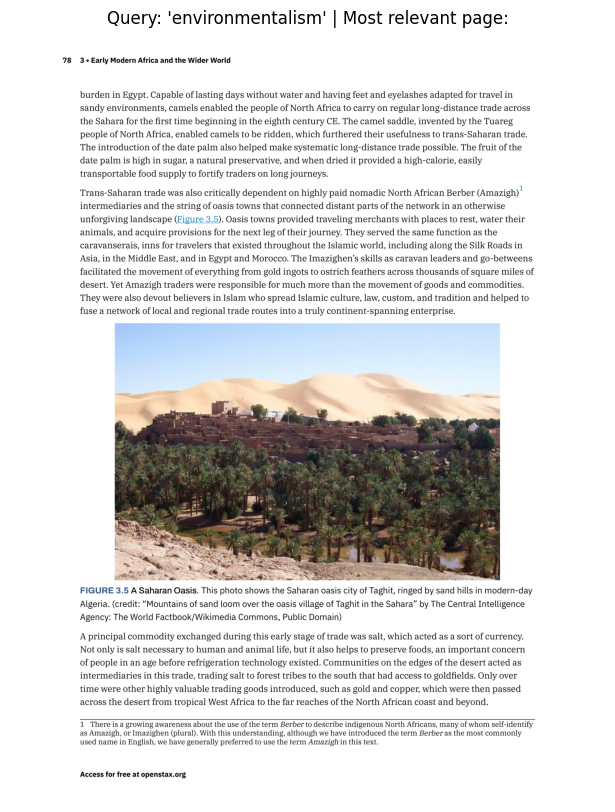

In [43]:
import fitz #pymupdf library

# Open PDF and load target page
pdf_path = "world-history-text.pdf" # requires PDF to be downloaded
doc = fitz.open(pdf_path)
page = doc.load_page(68 + 19) # number of page (our doc starts page numbers on page 41)

# Get the image of the page
img = page.get_pixmap(dpi=300)

# Optional: save the image
#img.save("output_filename.png")
doc.close()

# Convert the Pixmap to a numpy array
img_array = np.frombuffer(img.samples_mv,
                          dtype=np.uint8).reshape((img.h, img.w, img.n))

# Display the image using Matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(13, 10))
plt.imshow(img_array)
plt.title(f"Query: '{query}' | Most relevant page:")
plt.axis('off') # Turn off axis
plt.show()

Nice!

Now we can do extra research if we'd like.

We could repeat this workflow for any kind of query we'd like on our textbook.

And it would also work for other datatypes too.

We could use semantic search on customer support documents.

Or email threads.

Or company plans.

Or our old journal entries.

Almost anything!

The workflow is the same:

`ingest documents -> split into chunks -> embed chunks -> make a query -> embed the query -> compare query embedding to chunk embeddings`

And we get relevant resources *along with* the source they came from!

That's the **retrieval** part of Retrieval Augmented Generation (RAG).

Before we get to the next two steps, let's take a small aside and discuss similarity measures.

### Similarity measures: dot product and cosine similarity

Let's talk similarity measures between vectors.

Specifically, embedding vectors which are representations of data with magnitude and direction in high dimensional space (our embedding vectors have 1024 dimensions).

Two of the most common you'll across are the dot product and cosine similarity.

They are quite similar.

The main difference is that cosine similarity has a normalization step.

| Similarity measure | Description | Code |
| ----- | ----- | ----- |
| [Dot Product](https://en.wikipedia.org/wiki/Dot_product) | - Measure of magnitude and direction between two vectors<br>- Vectors that are aligned in direction and magnitude have a higher positive value<br>- Vectors that are opposite in direction and magnitude have a higher negative value | [`torch.dot`](https://pytorch.org/docs/stable/generated/torch.dot.html), [`np.dot`](https://numpy.org/doc/stable/reference/generated/numpy.dot.html), [`sentence_transformers.util.dot_score`](https://www.sbert.net/docs/package_reference/util.html#sentence_transformers.util.dot_score) |
| [Cosine Similarity](https://en.wikipedia.org/wiki/Cosine_similarity) | - Vectors get normalized by magnitude/[Euclidean norm](https://en.wikipedia.org/wiki/Norm_(mathematics))/L2 norm so they have unit length and are compared more so on direction<br>- Vectors that are aligned in direction have a value close to 1<br>- Vectors that are opposite in direction have a value close to -1 | [`torch.nn.functional.cosine_similarity`](https://pytorch.org/docs/stable/generated/torch.nn.functional.cosine_similarity.html), [`1 - scipy.spatial.distance.cosine`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cosine.html) (subtract the distance from 1 for similarity measure), [`sentence_transformers.util.cos_sim`](https://www.sbert.net/docs/package_reference/util.html#sentence_transformers.util.cos_sim) |

For text similarity, you generally want to use cosine similarity as you are after the semantic measurements (direction) rather than magnitude.

In our case, our embedding model `mxbai-embed-large-v1` outputs normalized vectors (see the [Hugging Face model card](https://huggingface.co/mixedbread-ai/mxbai-embed-large-v1) for more) so dot product and cosine similarity return the same results. However, dot product is faster because it skips the normalization step.

To make things bit more concrete, let's make simple dot product and cosine similarity functions and view their results on different vectors.

> **Note:** Similarity measures between vectors and embeddings can be used on any kind of embeddings, not just text embeddings. For example, you could measure image embedding similarity or audio embedding similarity. Or with text and image models like [CLIP](https://github.com/mlfoundations/open_clip), you can measure the similarity between text and image embeddings.

In [44]:
import torch

def dot_product(vector1, vector2):
    return torch.dot(vector1, vector2)

def cosine_similarity(vector1, vector2):
    dot_product = torch.dot(vector1, vector2)

    # Get Euclidean/L2 norm of each vector (removes the magnitude, keeps direction)
    norm_vector1 = torch.sqrt(torch.sum(vector1**2))
    norm_vector2 = torch.sqrt(torch.sum(vector2**2))

    return dot_product / (norm_vector1 * norm_vector2)

# Example tensors
vector1 = torch.tensor([1, 2, 3], dtype=torch.float32)
vector2 = torch.tensor([1, 2, 3], dtype=torch.float32)
vector3 = torch.tensor([4, 5, 6], dtype=torch.float32)
vector4 = torch.tensor([-1, -2, -3], dtype=torch.float32)

# Calculate dot product
print("Dot product between vector1 and vector2:", dot_product(vector1, vector2))
print("Dot product between vector1 and vector3:", dot_product(vector1, vector3))
print("Dot product between vector1 and vector4:", dot_product(vector1, vector4))

# Calculate cosine similarity
print("Cosine similarity between vector1 and vector2:", cosine_similarity(vector1, vector2))
print("Cosine similarity between vector1 and vector3:", cosine_similarity(vector1, vector3))
print("Cosine similarity between vector1 and vector4:", cosine_similarity(vector1, vector4))

Dot product between vector1 and vector2: tensor(14.)
Dot product between vector1 and vector3: tensor(32.)
Dot product between vector1 and vector4: tensor(-14.)
Cosine similarity between vector1 and vector2: tensor(1.0000)
Cosine similarity between vector1 and vector3: tensor(0.9746)
Cosine similarity between vector1 and vector4: tensor(-1.0000)


Notice for both dot product and cosine similarity the comparisons of `vector1` and `vector2` are the opposite of `vector1` and `vector4`.

Comparing `vector1` and `vector2` both equations return positive values (14 for dot product and 1.0 for cosine similarity).

But comparing `vector1` and `vector4` the result is in the negative direction.

This makes sense because `vector4` is the negative version of `vector1`.

Whereas comparing `vector1` and `vector3` shows a different outcome.

For the dot product, the value is positive and larger then the comparison of two exactly the same vectors (32 vs 14).

However, for the cosine similarity, thanks to the normalization step, comparing `vector1` and `vector3` results in a postive value close to 1 but not exactly 1.

It is because of this that when comparing text embeddings, cosine similarity is generally favoured as it measures the difference in direction of a pair of vectors rather than difference in magnitude.

And it is this difference in direction that is more generally considered to capture the semantic meaning/vibe of the text.

The good news is that as mentioned before, the outputs of our embedding model `mxbai-embed-large-v1` are already normalized.

So we can continue using the dot product (cosine similarity is dot product + normalization).

With similarity measures explained, let's functionize our semantic search steps from above so we can repeat them.

### Functionizing our semantic search pipeline

Let's put all of the steps from above for semantic search into a function or two so we can repeat the workflow.

In [45]:
def retrieve_relevant_resources(query: str,
                                embeddings: torch.tensor,
                                model: SentenceTransformer=embedding_model,
                                n_resources_to_return: int=5,
                                print_time: bool=True):
    """
    Embeds a query with model and returns top k scores and indices from embeddings.
    """

    # Embed the query
    # Cast to match the corpus dtype: the model returns float16 on GPU, but loaded embeddings are float32.
    query_embedding = model.encode(query,
                                   convert_to_tensor=True).to(embeddings.dtype)

    # Get dot product scores on embeddings
    start_time = timer()
    dot_scores = util.dot_score(query_embedding, embeddings)[0]
    end_time = timer()

    if print_time:
        print(f"[INFO] Time taken to get scores on {len(embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

    scores, indices = torch.topk(input=dot_scores,
                                 k=n_resources_to_return)

    return scores, indices

def print_top_results_and_scores(query: str,
                                 embeddings: torch.tensor,
                                 chunks: list[dict]=chunks,
                                 n_resources_to_return: int=5): #TODO: potential turn into a class?
    """
    Takes a query, retrieves most relevant resources and prints them out in descending order.

    Note: Requires chunks to be formatted in a specific way (see above for reference).
    """

    scores, indices = retrieve_relevant_resources(query=query,
                                                  embeddings=embeddings,
                                                  n_resources_to_return=n_resources_to_return)

    print(f"Query: {query}\n")
    print("Results:")
    # Loop through zipped together scores and indicies
    for score, index in zip(scores, indices):
        print(f"Score: {score:.4f}")
        # Print relevant sentence chunk (since the scores are in descending order, the most relevant chunk will be first)
        print_wrapped(chunks[index]["sentence_chunk"])
        # Print the page number too so we can reference the textbook further and check the results
        print(f"Page number: {chunks[index]['page_number']}")
        print("\n")

Excellent! Now let's test our functions out.

In [46]:
query = "causes of the industrial revolution"

# Get just the scores and indices of top related results
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)
scores, indices

[INFO] Time taken to get scores on 1777 embeddings: 0.00053 seconds.


(tensor([0.6254, 0.5779, 0.5380, 0.5288, 0.5148]),
 tensor([ 797,  918,  798, 1015,  795]))

In [47]:
# Print out the texts of the top scores
print_top_results_and_scores(query=query,
                             embeddings=embeddings)

[INFO] Time taken to get scores on 1777 embeddings: 0.00025 seconds.
Query: causes of the industrial revolution

Results:
Score: 0.6254
FIGURE 9.3 Locator Map: Expansion in the Industrial Age. (credit: modification
of work “World map blank shorelines” by Maciej Jaros/Wikimedia Commons, Public
Domain) 9.1 The Second Industrial Revolution LEARNING OBJECTIVES By the end of
this section, you will be able to: • Describe the technological innovations of
the Second Industrial Revolution • Describe the spread of industrialization
beyond western and central Europe and the United States • Explain the obstacles
to industrialization facing countries in Asia, North Africa, and Latin America
in the nineteenth century Great Britain was the first nation to enter the
Industrial Revolution, beginning to mechanize the production of goods in the
eighteenth century. It was followed by the United States, France, Belgium, and,
in the first half of the nineteenth century, by Germany. These nations harnessed
t

### Sanity check: is retrieval actually working?

Before we wire up the LLM, it's worth confirming the retrieval half of the pipeline is doing something sensible on its own. A good way to do this is to run two contrasting queries:

* An **on-topic** query that should clearly find relevant chunks in the textbook (e.g. something related to history). The top score should be reasonably high and the top chunk should obviously relate to the query.
* An **off-topic** query that the textbook has nothing useful to say about (e.g. `"what is the capital of France"`). The top score should be much lower, and the returned chunk should look unrelated.

If the off-topic query comes back with a similar score to the on-topic one, or returns the same chunks regardless of input, your retriever isn't actually discriminating between queries and connecting the LLM on top of it will only paper over the problem.

In [48]:
# Quick retrieval sanity check: one on-topic query and one obviously off-topic query.
# A healthy retriever should give a clearly higher top score to the on-topic query
# and return a chunk that visibly relates to it.
sanity_queries = [
    ("on-topic ",  "What are good sources of vitamin C?"),
    ("off-topic", "What is a molecule?"),
]

for label, query in sanity_queries:
    scores, indices = retrieve_relevant_resources(query=query,
                                                  embeddings=embeddings,
                                                  n_resources_to_return=1,
                                                  print_time=False)
    top_score = float(scores[0])
    top_chunk = chunks[int(indices[0])]["sentence_chunk"]
    print(f"[{label}] Query: {query}")
    print(f"  Top score: {top_score:.4f}")
    print(f"  Top chunk: {top_chunk[:300]}{'...' if len(top_chunk) > 300 else ''}")
    print()

[on-topic ] Query: What are good sources of vitamin C?
  Top score: 0.3144
  Top chunk: In the Aztec and Inca empires, large urban populations were ruled by monarchs. As part of the Columbian Exchange, Europeans introduced to the Americas the crops they were familiar with at home, including wheat; the Vitis vinifera species of grape; fruits such as pears, peaches, and many varieties of...

[off-topic] Query: What is a molecule?
  Top score: 0.1921
  Top chunk: Sudetenland, and Hitler agreed. The Munich Conference was attended by Chamberlain, Hitler, French prime minister Édouard Daladier, and Mussolini (ostensibly a neutral party but one who had already assured Hitler of his support). On September 30, they produced the Munich Pact, in which Czechoslovakia...



### Semantic search/vector search extensions

We've covered an exmaple of using embedding vector search to find relevant results based on a query.

However, you could also add to this pipeline with traditional keyword search.

Many modern search systems use keyword and vector search in tandem.

Our dataset is small and allows for an exhaustive search (comparing the query to *every* possible result) but if you start to work with large scale datasets with hundred of thousands, millions or even billions of vectors, you'll want to implement an index.

You can think of an index as sorting your embeddings before you search through them.

So it narrows down the search space.

For example, it would be inefficient to search every word in the dictionary to find the word "duck", instead you'd go straight to the letter D, perhaps even straight to the back half of the letter D, find words close to "duck" before finding it.

That's how an index can help search through many examples without comprimising too much on speed or quality (for more on this, check out [nearest neighbour search](https://en.wikipedia.org/wiki/Nearest_neighbor_search)).

One of the most popular indexing libraries is [Faiss](https://github.com/facebookresearch/faiss).

Faiss is open-source and was originally created by Facebook to deal with internet-scale vectors and implements many algorithms such as [HNSW](https://arxiv.org/abs/1603.09320) (Hierarchical Naviganle Small Worlds).

### Getting an LLM for local generation

We're got our retrieval pipeline ready, let's now get the generation side of things happening.

To perform generation, we're going to use a Large Language Model (LLM).

LLMs are designed to generate an output given an input.

In our case, we want our LLM to generate and output of text given a input of text.

And more specifically, we want the output of text to be generated based on the context of relevant information to the query.

The input to an LLM is often referred to as a prompt.

We'll augment our prompt with a query as well as context from our textbook related to that query.

> **Which LLM should I use?**

There are many LLMs available.

Two of the main questions to ask from this is:
1. Do I want it to run locally?
2. If yes, how much compute power can I dedicate?

If you're after the absolute best performance, you'll likely want to use an API (not running locally) such as GPT-4 or Claude 3. However, this comes with the tradeoff of sending your data away and then awaiting a response.

For our case, since we want to set up a local pipeline and run it on our own GPU, we'd answer "yes" to the first question and then the second question will depend on what hardware we have available.

To find open-source LLMs, one great resource is the [Hugging Face open LLM leaderboard](https://huggingface.co/spaces/HuggingFaceH4/open_llm_leaderboard).

The leaderboard compares many of the latest and greatest LLMs on various benchmarks.

Another great resource is [TheBloke on Hugging Face](https://huggingface.co/TheBloke), an account which provides an extensive range of quantized (models that have been made smaller) LLMs.

A rule of thumb for LLMs (and deep learning models in general) is that the higher the number of parameters, the better the model performs.

It may be tempting to go for the largest size model (e.g. a 70B parameter model rather than a 7B parameter model) but a larger size model may not be able to run on your available hardware.

The following table gives an insight into how much GPU memory you'll need to load an LLM with different sizes and different levels of [numerical precision](https://en.wikipedia.org/wiki/Precision_(computer_science)).

They are based on the fact that 1 float32 value (e.g. `0.69420`) requires 4 bytes of memory and 1GB is approximately 1,000,000,000 (one billion) bytes.

| Model Size (Billion Parameters) | Float32 VRAM (GB) | Float16 VRAM (GB) | 8-bit VRAM (GB) | 4-bit VRAM (GB) |
|-----|-----|-----|-----|-----|
| 1B                              | ~4                | ~2                | ~1              | ~0.5            |
| 3B (e.g., [Qwen2.5 3B](https://huggingface.co/Qwen/Qwen2.5-3B-Instruct))             | ~12               | ~6                | ~3              | ~1.5            |
| 4B (e.g., [Gemma 3 4B](https://huggingface.co/google/gemma-3-4b-it))             | ~16               | ~8                | ~4              | ~2              |
| 7B-8B (e.g., [Llama 3.1 8B](https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct), [Mistral 7B](https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.3))             | ~28-32            | ~14-16            | ~7-8            | ~3.5-4          |
| 10B                             | ~40               | ~20               | ~10             | ~5              |
| 70B (e.g., [Llama 3.1 70B](https://huggingface.co/meta-llama/Llama-3.1-70B-Instruct))          | ~280              | ~140              | ~70             | ~35             |
| 100B                            | ~400              | ~200              | ~100            | ~50             |
| 175B                            | ~700              | ~350              | ~175            | ~87.5           |

<br>

> **Note:** Loading a model in a lower precision (e.g. 8-bit instead of float16) generally lowers performance. Lower precision can help to reduce computing requirements, however sometimes the performance degradation in terms of model output can be substantial. Finding the right speed/performance tradeoff will often require many experiments.

### Checking local hardware availability

Let's find out what hardware we've got available and pick a model that will actually fit and run at a reasonable speed.

There are three cases we care about:
1. **NVIDIA GPU (CUDA)** the fastest option; we look at VRAM to decide the model size.
2. **Apple Silicon (MPS)** M1/M2/M3/M4 Macs; we can use the GPU via Metal Performance Shaders for a big speedup.
3. **CPU-only** works everywhere, but inference is slow, so we default to a much smaller LLM.

> **Note:** On NVIDIA setups you can also inspect VRAM with `!nvidia-smi`.

In [49]:
import torch

# Figure out the available memory so we can pick a sensible model size.
# - cuda: we can ask the driver for total VRAM.
# - mps:  there's no separate VRAM (unified memory on Apple Silicon); use system RAM as a proxy.
# - cpu:  use system RAM.
if device == "cuda":
    gpu_memory_bytes = torch.cuda.get_device_properties(0).total_memory
    gpu_memory_gb = round(gpu_memory_bytes / (2**30))
    print(f"Detected NVIDIA GPU with ~{gpu_memory_gb} GB VRAM")
else:
    try:
        import psutil
        system_memory_gb = round(psutil.virtual_memory().total / (2**30))
    except ImportError:
        import os
        system_memory_gb = round(os.sysconf("SC_PAGE_SIZE") * os.sysconf("SC_PHYS_PAGES") / (2**30)) if hasattr(os, "sysconf") else 8
    gpu_memory_gb = 0  # signal that we don't have a CUDA GPU; the selector below uses this.
    print(f"No NVIDIA GPU detected. device={device}, system RAM ~{system_memory_gb} GB")

No NVIDIA GPU detected. device=cpu, system RAM ~16 GB


Now we pick an LLM based on what hardware we just detected.

**If you have an NVIDIA GPU** with ~8GB+ of VRAM, we default to Google's [`gemma-3-4b-it`](https://huggingface.co/google/gemma-3-4b-it) ("it" stands for Instruction-Tuned) at bfloat16 — a compact, capable 4B-parameter model. With less VRAM we fall back to [`Qwen/Qwen2.5-3B-Instruct`](https://huggingface.co/Qwen/Qwen2.5-3B-Instruct), which runs comfortably in ~6GB.

**If you're on Apple Silicon or CPU-only**, those 3B-4B models will technically load, but generation will be slow (tens of seconds to minutes per answer). We default to a much smaller instruction-tuned model so the tutorial is actually interactive: [`Qwen/Qwen2.5-1.5B-Instruct`](https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct). On Apple Silicon you can usually step up to 3B or 4B comfortably; on plain CPU, consider going even smaller with [`Qwen/Qwen2.5-0.5B-Instruct`](https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct).

Instruction tuning is the process of tuning a raw language model to follow instructions. These are the kind of models you'll find in most chat-based assistants such as ChatGPT, Gemini, or Claude.

The following table shows approximate memory requirements for our default and alternative models at different precisions.

| Model             | Precision | Recommended memory (GB) | Hugging Face ID |
|-------------------|-----------|--------------------------|-----------------|
| Qwen2.5 0.5B Instruct | Float32   | ~2 | [`Qwen/Qwen2.5-0.5B-Instruct`](https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct) |
| Qwen2.5 1.5B Instruct | Float32   | ~6 | [`Qwen/Qwen2.5-1.5B-Instruct`](https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct) |
| Qwen2.5 3B Instruct   | bfloat16  | ~6 | [`Qwen/Qwen2.5-3B-Instruct`](https://huggingface.co/Qwen/Qwen2.5-3B-Instruct) |
| Gemma 3 4B Instruct   | bfloat16  | ~8 | [`google/gemma-3-4b-it`](https://huggingface.co/google/gemma-3-4b-it) |

> **Note:** "instruction tuned" (the `-it` suffix on Gemma, `-Instruct` on Qwen) means a base LLM has been fine-tuned to follow instructions, making it suitable for chat-style prompts. On CPU we keep models in float32 because most CPUs don't have native bfloat16 / float16 paths and accuracy is more important than the tiny memory saving.

Based on the table above, here's the selector logic.

In [50]:
# Pick a model based on the detected device + memory.
# - On CUDA we use VRAM as the gate.
# - On MPS / CPU we default to a much smaller model so generation actually completes in seconds, not minutes.
# SWAP: change `model_id` below to any HF causal LM with a chat template you like (e.g. "meta-llama/Llama-3.2-3B-Instruct").
use_quantization_config = False

if device == "cuda":
    if gpu_memory_gb < 3.0:
        print(f"VRAM ~{gpu_memory_gb} GB | very tight; using Qwen2.5-3B-Instruct in 4-bit (requires bitsandbytes).")
        model_id = "Qwen/Qwen2.5-3B-Instruct"
        use_quantization_config = True
    elif gpu_memory_gb < 8.0:
        print(f"VRAM ~{gpu_memory_gb} GB | using Qwen2.5-3B-Instruct in bfloat16.")
        model_id = "Qwen/Qwen2.5-3B-Instruct"
    else:
        print(f"VRAM ~{gpu_memory_gb} GB | using Gemma 3 4B Instruct in bfloat16.")
        model_id = "google/gemma-3-4b-it"
elif device == "mps":
    # Apple Silicon: GPU via Metal. Unified memory, so the LLM shares RAM with the rest of the OS.
    # Default to 0.5B so we fit comfortably even on 8 GB base-model M-series machines.
    # SWAP up: "Qwen/Qwen2.5-1.5B-Instruct" (better answers, ~3 GB) on 16 GB+ Macs,
    #          "Qwen/Qwen2.5-3B-Instruct" (~6 GB) on 24 GB+ Macs.
    print(f"device=mps (Apple Silicon) | using Qwen2.5-0.5B-Instruct.")
    model_id = "Qwen/Qwen2.5-0.5B-Instruct"
else:
    # CPU: default to 0.5B so generation completes in ~5-15 seconds per answer.
    # SWAP up: "Qwen/Qwen2.5-1.5B-Instruct" gives noticeably better answers but ~30-60 s/answer on a quad-core CPU.
    print(f"device=cpu | using Qwen2.5-0.5B-Instruct.")
    model_id = "Qwen/Qwen2.5-0.5B-Instruct"

print(f"use_quantization_config set to: {use_quantization_config}")
print(f"model_id set to: {model_id}")

device=cpu | using Qwen2.5-0.5B-Instruct.
use_quantization_config set to: False
model_id set to: Qwen/Qwen2.5-0.5B-Instruct


### Loading an LLM locally

Alright! With `model_id` and `use_quantization_config` set based on our available VRAM, let's load the LLM (change those values above if you want to try a different model).

The Hugging Face [`transformers`](https://huggingface.co/docs/transformers/) library has all the tools we need.

To load our LLM, we're going to need a few things:
1. A quantization config (optional) - Loads the model in 4-bit precision for lower memory usage. Built with [`transformers.BitsAndBytesConfig`](https://huggingface.co/docs/transformers/main_classes/quantization#transformers.BitsAndBytesConfig), which requires the optional [`bitsandbytes` library](https://github.com/bitsandbytes-foundation/bitsandbytes) (Linux/CUDA only; skip on Windows/Mac).
2. A model ID - The Hugging Face model ID that determines which tokenizer and model get loaded (e.g. `google/gemma-3-4b-it`).
3. A tokenizer - Turns raw text into tokens ready for the model. We create it with [`transformers.AutoTokenizer.from_pretrained`](https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoTokenizer).
4. An LLM model - Loaded with [`transformers.AutoModelForCausalLM.from_pretrained`](https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoModelForCausalLM.from_pretrained), passing the model ID along with other parameters.

As a bonus, we'll check whether [Flash Attention 2](https://huggingface.co/docs/transformers/perf_infer_gpu_one#flashattention-2) is available using `transformers.utils.is_flash_attn_2_available()`. Flash Attention 2 speeds up the attention mechanism in Transformer models. If it isn't installed or supported, we'll cleanly fall back to `sdpa` (PyTorch's built-in scaled dot product attention), so this step won't crash on non-Ampere GPUs.

> **Note:** Flash Attention 2 currently works on NVIDIA GPUs with compute capability 8.0+ (Ampere, Ada Lovelace, Hopper architectures). You can check your GPU's compute capability with [`torch.cuda.get_device_capability(0)`](https://pytorch.org/docs/stable/generated/torch.cuda.get_device_capability.html).

> **Note:** To get access to the Gemma models, you'll need to [accept the terms](https://huggingface.co/google/gemma-3-4b-it) on the Gemma model page on Hugging Face and authenticate via the [Hugging Face CLI / `login()`](https://huggingface.co/docs/huggingface_hub/quick-start#authentication). In Google Colab, add a [Hugging Face token](https://huggingface.co/docs/hub/security-tokens) to the "Secrets" tab. Qwen2.5-3B-Instruct is openly accessible and does not require accepting any terms.
>
> Downloading an LLM locally can take a few minutes depending on your connection. Gemma 3 4B is about an 8GB download, and Qwen2.5-3B-Instruct is around 6GB.

Let's do it!

In [51]:
# flash-attn is an optional NVIDIA-only speedup. We don't install it here in offline mode -- if you
# wanted it, you'd have built it into your env beforehand. The notebook always falls back to sdpa,
# which is built into PyTorch and works on cuda / mps / cpu.
print("[INFO] flash-attn install skipped (offline mode). Will use sdpa.")

[INFO] flash-attn install skipped (offline mode). Will use sdpa.


In [52]:
# `accelerate` is already installed via requirements.txt. Skipping pip install.
# `bitsandbytes` (optional, for 4-bit quantization on CUDA only) is also intentionally NOT
# installed in this offline-mode notebook -- if you needed it, you'd have set it up beforehand.

In [53]:
# In offline mode we don't need to log in to Hugging Face -- the cached models are read directly
# from disk, no auth is required. If you swap to a gated model (e.g. google/gemma-*, meta-llama/*),
# you'd need to switch off offline mode, log in, accept the license, and re-download. That's
# outside the scope of this offline notebook.
print(f"[INFO] Offline mode; using cached '{model_id}'. No Hugging Face login required.")

[INFO] Offline mode; using cached 'Qwen/Qwen2.5-0.5B-Instruct'. No Hugging Face login required.


In [54]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# Pick a *separate* device for the LLM. The embedding model is happy on MPS, but on memory-tight
# Apple Silicon Macs the LLM frequently OOMs there (small allocator ceiling + sticky cached allocs).
# Running the LLM on CPU is rock-solid; Qwen 0.5B / 1.5B at fp32 fits in regular RAM and is still
# usable speed on M-series chips.
if device == "cuda":
    llm_device = "cuda"
else:
    llm_device = "cpu"
print(f"[INFO] LLM will run on: {llm_device} (embeddings stay on '{device}')")

# Pick a dtype that's appropriate for the LLM device.
# - cuda: bfloat16 (Gemma 3 and most modern LLMs need the wide exponent range; fp16 NaNs out)
# - cpu:  float32 (most reliable; CPUs lack native bf16/fp16 paths anyway)
if llm_device == "cuda":
    model_dtype = torch.bfloat16
else:
    model_dtype = torch.float32
print(f"[INFO] Using dtype: {model_dtype}")

# Create quantization config for smaller model loading (optional, requires bitsandbytes).
# bitsandbytes is Linux/CUDA-only, so we only even try this on cuda.
quantization_config = None
if use_quantization_config and llm_device == "cuda":
    try:
        from transformers import BitsAndBytesConfig
        quantization_config = BitsAndBytesConfig(load_in_4bit=True,
                                                 bnb_4bit_compute_dtype=torch.bfloat16)
    except Exception as e:
        print(f"[WARN] Could not build BitsAndBytesConfig ({e.__class__.__name__}); falling back to {model_dtype} without quantization.")
        use_quantization_config = False
elif use_quantization_config:
    print(f"[WARN] 4-bit quantization requested but llm_device={llm_device} doesn't support bitsandbytes. Falling back to {model_dtype}.")
    use_quantization_config = False

# 3. Bonus: try Flash Attention 2 for faster inference on Ampere+ NVIDIA GPUs; fall back to "sdpa" otherwise.
# sdpa is built into PyTorch and works fine on cuda / mps / cpu.
try:
    from transformers.utils import is_flash_attn_2_available
    fa2_ok = is_flash_attn_2_available() and torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8
except Exception:
    fa2_ok = False
attn_implementation = "flash_attention_2" if fa2_ok else "sdpa"
print(f"[INFO] Using attention implementation: {attn_implementation}")

# 4. Pick a model (already chosen above based on available hardware)
# SWAP: change `model_id` here to any HF causal LM with a chat template, e.g. "Qwen/Qwen2.5-7B-Instruct" or "meta-llama/Llama-3.2-3B-Instruct"
print(f"[INFO] Using model_id: {model_id}")

# 5. Instantiate tokenizer (turns text into token IDs ready for the model)
# local_files_only=True forces offline mode -- never hits the network, only reads the local HF cache.
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=model_id,
                                          local_files_only=True)

# 6. Instantiate the model (also offline; cached weights only)
llm_model = AutoModelForCausalLM.from_pretrained(pretrained_model_name_or_path=model_id,
                                                 torch_dtype=model_dtype,
                                                 quantization_config=quantization_config,
                                                 low_cpu_mem_usage=False,
                                                 attn_implementation=attn_implementation,
                                                 local_files_only=True)

# Move the model to the chosen LLM device (bitsandbytes-quantized models manage their own placement).
if not use_quantization_config:
    llm_model.to(llm_device)

[INFO] LLM will run on: cpu (embeddings stay on 'cpu')
[INFO] Using dtype: torch.float32
[INFO] Using attention implementation: sdpa
[INFO] Using model_id: Qwen/Qwen2.5-0.5B-Instruct


We've got an LLM!

Let's check it out.

In [55]:
llm_model

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2SdpaAttention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
          (rotary_emb): Qwen2RotaryEmbedding()
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((

Ok, ok a bunch of layers ranging from embedding layers to attention layers (look for the attention class name in your model's output, e.g. `Gemma3Attention` or `Qwen2Attention`) to MLP and normalization layers.

The good news is that we don't have to know too much about these to use the model.

How about we get the number of parameters in our model?

In [56]:
def get_model_num_params(model: torch.nn.Module):
    return sum([param.numel() for param in model.parameters()])

get_model_num_params(llm_model)

494032768

Hmm, model "size" names (3B, 4B, 7B) are usually approximate; the actual parameter count above is the real number.

It pays to do your own investigations!

How about we get the model's memory requirements?

In [57]:
def get_model_mem_size(model: torch.nn.Module):
    """
    Get how much memory a PyTorch model takes up.

    See: https://discuss.pytorch.org/t/gpu-memory-that-model-uses/56822
    """
    # Get model parameters and buffer sizes
    mem_params = sum([param.nelement() * param.element_size() for param in model.parameters()])
    mem_buffers = sum([buf.nelement() * buf.element_size() for buf in model.buffers()])

    # Calculate various model sizes
    model_mem_bytes = mem_params + mem_buffers # in bytes
    model_mem_mb = model_mem_bytes / (1024**2) # in megabytes
    model_mem_gb = model_mem_bytes / (1024**3) # in gigabytes

    return {"model_mem_bytes": model_mem_bytes,
            "model_mem_mb": round(model_mem_mb, 2),
            "model_mem_gb": round(model_mem_gb, 2)}

get_model_mem_size(llm_model)

{'model_mem_bytes': 1976134272, 'model_mem_mb': 1884.59, 'model_mem_gb': 1.84}

Nice, that gives us a feel for how much GPU memory the weights alone occupy.

Add a little more for the forward pass (due to all the calculations happening between the layers, plus the KV cache during generation).

That's why the "Recommended VRAM" column in the table above is a bit higher than the raw weights size.

Now let's get to the fun part, generating some text!

### Generating text with our LLM

We can generate text with our LLM `model` instance by calling the [`generate()` method](https://huggingface.co/docs/transformers/v4.38.2/en/main_classes/text_generation#transformers.GenerationConfig) (this method has plenty of options to pass into it alongside the text) on it and passing it a tokenized input.

The tokenized input comes from passing a string of text to our `tokenizer`.

It's important to note that you should use a tokenizer that has been paired with a model.

Otherwise if you try to use a different tokenizer and then pass those inputs to a model, you will likely get errors/strange results.

For some LLMs, there's a specific template you should pass to them for ideal outputs.

For example, instruction-tuned models like `gemma-3-4b-it` and `Qwen2.5-3B-Instruct` have been trained in a dialogue fashion.

In this case, our `tokenizer` has an [`apply_chat_template()` method](https://huggingface.co/docs/transformers/main/internal/tokenization_utils#transformers.PreTrainedTokenizerBase.apply_chat_template) which can prepare our input text in the right format for the model.

Let's try it out.

> **Note:** The chat template is automatically picked up from the tokenizer for whichever model you loaded. Demos of usage are available on each model's Hugging Face model card (e.g. [Gemma 3 4B](https://huggingface.co/google/gemma-3-4b-it), [Qwen2.5 3B Instruct](https://huggingface.co/Qwen/Qwen2.5-3B-Instruct)).

In [58]:
input_text = "What is environmentalism?"
print(f"Input text:\n{input_text}")

# Create prompt template for instruction-tuned model
dialogue_template = [
    {"role": "user",
     "content": input_text}
]

# Apply the chat template
prompt = tokenizer.apply_chat_template(conversation=dialogue_template,
                                       tokenize=False, # keep as raw text (not tokenized)
                                       add_generation_prompt=True)
print(f"\nPrompt (formatted):\n{prompt}")

Input text:
What is environmentalism?

Prompt (formatted):
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
What is environmentalism?<|im_end|>
<|im_start|>assistant



Notice the scaffolding around our input text, this is the kind of turn-by-turn instruction tuning our model has gone through.

Our next step is to tokenize this formatted text and pass it to our model's `generate()` method.

We'll make sure our tokenized text lives on the same device as our model (whatever `device` resolved to: cuda / mps / cpu) using `.to(device)`.

Let's generate some text!

We'll time it for fun with the `%%time` magic.

In [59]:
%%time

# Tokenize the input text (turn it into numbers) and send it to the chosen device.
# `add_special_tokens=False` because the chat template already inserted any required special tokens
# (e.g. Gemma's <bos>); without this we'd get a double-BOS that degrades Gemma's outputs.
input_ids = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).to(llm_device)
print(f"Model input (tokenized):\n{input_ids}\n")

# Generate outputs passed on the tokenized input
# See generate docs: https://huggingface.co/docs/transformers/v4.38.2/en/main_classes/text_generation#transformers.GenerationConfig
outputs = llm_model.generate(**input_ids,
                             max_new_tokens=256) # define the maximum number of new tokens to create
print(f"Model output (tokens):\n{outputs[0]}\n")

Model input (tokenized):
{'input_ids': tensor([[151644,   8948,    198,   2610,    525,   1207,  16948,     11,   3465,
            553,  54364,  14817,     13,   1446,    525,    264,  10950,  17847,
             13, 151645,    198, 151644,    872,    198,   3838,    374,  12158,
           2142,     30, 151645,    198, 151644,  77091,    198]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

Model output (tokens):
tensor([151644,   8948,    198,   2610,    525,   1207,  16948,     11,   3465,
           553,  54364,  14817,     13,   1446,    525,    264,  10950,  17847,
            13, 151645,    198, 151644,    872,    198,   3838,    374,  12158,
          2142,     30, 151645,    198, 151644,  77091,    198,  82066,   2142,
         19257,    311,    279,   3920,    323,  34854,    369,  22184,    323,
         46895,    279,   5810,   4573,    323,  22136,  21803,   4401,    304,
     

Woohoo! We just generated some text on our local GPU!

Well not just yet...

Our LLM accepts tokens in and sends tokens back out.

We can conver the output tokens to text using [`tokenizer.decode()`](https://huggingface.co/docs/transformers/main_classes/tokenizer#transformers.PreTrainedTokenizer.decode).

In [60]:
# Decode the output tokens to text
outputs_decoded = tokenizer.decode(outputs[0])
print(f"Model output (decoded):\n{outputs_decoded}\n")

Model output (decoded):
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
What is environmentalism?<|im_end|>
<|im_start|>assistant
Environmentalism refers to the study and advocacy for protecting and preserving the natural environment and promoting sustainable development in human society. It involves efforts to reduce pollution, conserve resources, and protect biodiversity.

Key aspects of environmentalism include:

1. Conservation: Protecting ecosystems, forests, and other natural habitats from destruction.
2. Sustainable Development: Promoting economic growth that does not harm the environment or the well-being of future generations.
3. Public Awareness: Increasing public understanding and awareness about environmental issues through education and media.
4. Policy Advocacy: Engaging policymakers to develop policies that promote sustainability and conservation.
5. Corporate Responsibility: Encouraging companies to adop

Woah! That looks like a pretty good answer.

But notice how the output contains the prompt text as well?

How about we do a little formatting to replace the prompt in the output text?

> **Note:** `"<bos>"` and `"<eos>"` are special tokens to denote "beginning of sentence" and "end of sentence" respectively.

In [61]:
print(f"Input text: {input_text}\n")
print(f"Output text:\n{outputs_decoded.replace(prompt, '').replace('<bos>', '').replace('<eos>', '')}")

Input text: What is environmentalism?

Output text:
Environmentalism refers to the study and advocacy for protecting and preserving the natural environment and promoting sustainable development in human society. It involves efforts to reduce pollution, conserve resources, and protect biodiversity.

Key aspects of environmentalism include:

1. Conservation: Protecting ecosystems, forests, and other natural habitats from destruction.
2. Sustainable Development: Promoting economic growth that does not harm the environment or the well-being of future generations.
3. Public Awareness: Increasing public understanding and awareness about environmental issues through education and media.
4. Policy Advocacy: Engaging policymakers to develop policies that promote sustainability and conservation.
5. Corporate Responsibility: Encouraging companies to adopt environmentally friendly practices and support sustainable development initiatives.
6. Community Engagement: Involving local communities in env

How cool is that!

We just officially generated text from an LLM running locally.

So we've covered the R (retrieval) and G (generation) of RAG.

How about we check out the last step?

Augmentation.

First, let's put together a list of queries we can try out with our pipeline.

In [62]:
# Post-1400 world history questions
factual_questions = [
    "What were the main causes of the Protestant Reformation?",
    "How did the French Revolution influence political thought across Europe?",
    "What were the main causes and consequences of World War One?"
]

specific_questions = [
    "What was the significance of the Treaty of Westphalia in 1648?",
    "How did the Ottoman Empire decline during the 19th century?",
    "What role did nationalism play in the unification of Germany and Italy?",
    "How did the Industrial Revolution begin in Britain and spread to other countries?",
    "What were the causes and outcomes of the American Revolution?"
]

tricky_questions = [
    "What caused the fall of the Roman Empire?",  # pre-1400, tests retrieval boundaries
    "Who built the pyramids?",                    # way out of scope
    "What is the capital of France?",             # completely off-topic
]

query_list = factual_questions + specific_questions

And now let's check if our `retrieve_relevant_resources()` function works with our list of queries.

In [63]:
import random
query = random.choice(query_list)

print(f"Query: {query}")

# Get just the scores and indices of top related results
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)
scores, indices

Query: What was the significance of the Treaty of Westphalia in 1648?
[INFO] Time taken to get scores on 1777 embeddings: 0.00089 seconds.


(tensor([0.5588, 0.4920, 0.4755, 0.4580, 0.4424]),
 tensor([ 412, 1212, 1354, 1067,  146]))

Beautiful!

Let's augment!

### Augmenting our prompt with context items

What we'd like to do with augmentation is take the results from our search for relevant resources and put them into the prompt that we pass to our LLM.

In essence, we start with a base prompt and update it with context text.

Let's write a function called `prompt_formatter` that takes in a query and our list of context items (in our case it'll be select indices from our list of dictionaries inside `chunks`) and then formats the query with text from the context items.

We'll apply the dialogue and chat template to our prompt before returning it as well.

> **Note:** The process of augmenting or changing a prompt to an LLM is known as prompt engineering. And the best way to do it is an active area of research. For a comprehensive guide on different prompt engineering techniques, I'd recommend the Prompt Engineering Guide ([promptingguide.ai](https://www.promptingguide.ai/)), [Brex's Prompt Engineering Guide](https://github.com/brexhq/prompt-engineering) and the paper [Prompt Design and Engineering: Introduction and Advanced Models](https://arxiv.org/abs/2401.14423).

In [64]:
def prompt_formatter(query: str,
                     context_items: list[dict]) -> str:
    """
    Augments query with text-based context from context_items.
    """
    # Join context items into one dotted paragraph
    context = "- " + "\n- ".join([item["sentence_chunk"] for item in context_items])

    # Create a base prompt with examples to help the model
    # Note: this is very customizable, I've chosen to use 3 examples of the answer style we'd like.
    # We could also write this in a txt file and import it in if we wanted.
    # SWAP: edit the `base_prompt` triple-quoted string below to change the system instructions, examples, or answer style for your own use case.
    base_prompt = """Based on the following context items, please answer the query:
{context}
\nRelevant passages: <extract relevant passages from the context here>
User query: {query}
Answer:"""

    # Update base prompt with context items and query
    base_prompt = base_prompt.format(context=context, query=query)

    # Create prompt template for instruction-tuned model
    dialogue_template = [
        {"role": "user",
        "content": base_prompt}
    ]

    # Apply the chat template
    prompt = tokenizer.apply_chat_template(conversation=dialogue_template,
                                          tokenize=False,
                                          add_generation_prompt=True)
    return prompt

Looking good! Let's try our function out.

In [65]:
query = random.choice(query_list)
print(f"Query: {query}")

# Get relevant resources
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)

# Create a list of context items
context_items = [chunks[i] for i in indices]

# Format prompt with context items
prompt = prompt_formatter(query=query,
                          context_items=context_items)
print(prompt)

Query: What were the causes and outcomes of the American Revolution?
[INFO] Time taken to get scores on 1777 embeddings: 0.00042 seconds.
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Based on the following context items, please answer the query:
- The Crown’s subsequent attempt to institute a land tax on aristocrats, who had previously been exempt from such assessments, resulted in broad resistance from social elites reluctant to surrender their traditional privileges. Meanwhile, the growing middle class, resentful of its exclusion from political power, agitated for change inspired by the Enlightenment rhetoric of rights and liberties. Demands for the reform of an antiquated system of government and social hierarchy reached a point of no return in the mid-1780s. Whereas the American Revolutionary War resulted in the birth of an independent new nation, the French Revolution radically restructured long-standing politic

What a good looking prompt!

We can tokenize this and pass it straight to our LLM.

In [66]:
%%time

# add_special_tokens=False: chat template already added any leading <bos>; avoids double-BOS on Gemma.
input_ids = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).to(llm_device)

# Generate an output of tokens
outputs = llm_model.generate(**input_ids,
                             temperature=0.7, # lower temperature = more deterministic outputs, higher temperature = more creative outputs
                             do_sample=True, # whether or not to use sampling, see https://huyenchip.com/2024/01/16/sampling.html for more
                             max_new_tokens=256) # how many new tokens to generate from prompt

# Turn the output tokens into text
output_text = tokenizer.decode(outputs[0])

print(f"Query: {query}")
print(f"RAG answer:\n{output_text.replace(prompt, '')}")

Query: What were the causes and outcomes of the American Revolution?
RAG answer:
The American Revolution, which occurred between 1775 and 1783, was driven by various factors. Initially, there was a strong desire among the colonists to establish a new nation and avoid the drawbacks of the British monarchy. The colonists felt that they had been unfairly treated by the British crown and had suffered under the oppressive taxation policies. This sentiment grew stronger as the colony's economy declined and faced severe economic difficulties, leading to calls for self-determination.

Additionally, the growing discontent among the population with the British monarchy and their own governance also played a role. The colonists saw themselves as representatives of their country and demanded better treatment from the crown. They also recognized the need for greater representation in the legislative body, as they believed that only by gaining this recognition could they gain the right to participat

Yesssssss!!!

Our RAG pipeline is complete!

We just Retrieved, Augmented and Generated!

And all on our own local GPU!

How about we functionize the generation step to make it easier to use?

We can put a little formatting on the text being returned to make it look nice too.

And we'll make an option to return the context items if needed as well.

In [67]:
def ask(query,
        temperature=0.7,
        max_new_tokens=512,
        format_answer_text=True,
        return_answer_only=True):
    """
    Takes a query, finds relevant resources/context and generates an answer to the query based on the relevant resources.
    """

    # Get just the scores and indices of top related results
    scores, indices = retrieve_relevant_resources(query=query,
                                                  embeddings=embeddings)

    # Create a list of context items
    context_items = [chunks[i] for i in indices]

    # Add score to context item
    for i, item in enumerate(context_items):
        item["score"] = scores[i].cpu() # return score back to CPU

    # Format the prompt with context items
    prompt = prompt_formatter(query=query,
                              context_items=context_items)

    # Tokenize the prompt
    # add_special_tokens=False: chat template already added any leading <bos>; avoids double-BOS on Gemma.
    input_ids = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).to(llm_device)

    # Generate an output of tokens
    outputs = llm_model.generate(**input_ids,
                                 temperature=temperature,
                                 do_sample=True,
                                 max_new_tokens=max_new_tokens)

    # Turn the output tokens into text
    output_text = tokenizer.decode(outputs[0])

    if format_answer_text:
        # Replace special tokens and unnecessary help message
        output_text = output_text.replace(prompt, "").replace("<bos>", "").replace("<eos>", "").replace("Sure, here is the answer to the user query:\n\n", "")

    # Only return the answer without the context items
    if return_answer_only:
        return output_text

    return output_text, context_items

What a good looking function!

The workflow could probably be a little refined but this should work!

Let's try it out.

In [68]:
query = random.choice(query_list)
print(f"Query: {query}")

# Answer query with context and return context
answer, context_items = ask(query=query,
                            temperature=0.7,
                            max_new_tokens=512,
                            return_answer_only=False)

print(f"Answer:\n")
print_wrapped(answer)
print(f"Context items:")
context_items

Query: What was the significance of the Treaty of Westphalia in 1648?
[INFO] Time taken to get scores on 1777 embeddings: 0.00021 seconds.
Answer:

The Treaty of Westphalia, signed in 1648, is considered a defining moment in
modern history. It established the principles of state sovereignty and the right
to self-determination of nations. The treaty affirmed the independence of each
nation-state and recognized the inherent rights of individual states, rather
than relying on external powers to enforce their laws. This shift in power
dynamics led to the formation of independent nation-states like the United
Kingdom, France, and other European powers.  Key points about the Treaty of
Westphalia:  1. **Established Independence**: It granted each nation-state the
right to self-governance without external interference.  2. **Independence vs.
Sovereignty**: The treaty acknowledged the inherent rights of individual
nations, challenging the absolute monarchies that had governed much of Europe
sin

[{'page_number': 154,
  'sentence_chunk': 'France joined in on the side of the Protestants, primarily in an effort to become the preeminent power in Europe. Despite the multinational nature of the combatants, battles were fought almost entirely within the German lands, whose people suffered as armies of mercenaries destroyed farms and villages. In the end, the German Protestants were victorious, and France had become the dominant country in western Europe. The Peace of Westphalia, which ended the war in 1648, established the independence of each of the entities, numbering nearly one thousand, that had made up the Holy Roman Empire. 5.2 Crossing the Atlantic LEARNING OBJECTIVES By the end of this section, you will be able to: • Explain how technological innovations in the fifteenth century made transatlantic journeys possible • Discuss the motives for Spanish and Portuguese exploration in the Americas • Analyze the impact of the Treaty of Tordesillas on the Atlantic World • Describe the

### Minimal evaluation: re-run the same query a few times

Before declaring victory, it's worth doing a tiny consistency check.

A reasonable RAG system should produce *similar* answers when asked the same question multiple times, even with `temperature=0.7`. If the three answers below disagree meaningfully (different facts, different conclusions, different topics), that's a signal one of two things is happening:

1. **Retrieved context is too vague.** The retriever pulled chunks that don't actually answer the question, so the LLM is filling in the blanks differently each time.
2. **The prompt needs tightening.** The instructions in `prompt_formatter` leave too much room for stylistic or interpretive variation, so the model wanders.

This is a quick, no-library smoke test, not a proper eval. For a real evaluation you'd build a fixed set of (query, expected answer) pairs and score them automatically. But this one cell catches a surprising number of regressions during prototyping.

In [69]:
# Run the same query three times at temperature=0.7 and compare the answers.
# Inconsistent answers at the same temperature often mean the retrieved context is too vague
# or the prompt needs tightening (see the markdown above).
eval_query = "What is environmentalism?"

print(f"Query: {eval_query}\n")
for run_idx in range(3):
    answer = ask(query=eval_query,
                 temperature=0.7,
                 max_new_tokens=512,
                 return_answer_only=True)
    print(f"--- Run {run_idx + 1} ---")
    print_wrapped(answer.strip())
    print()

Query: What is environmentalism?

[INFO] Time taken to get scores on 1777 embeddings: 0.00016 seconds.
--- Run 1 ---
Environmentalism is a movement that advocates protecting and preserving the
environment, recognizing that humans have made significant impacts on the
Earth's ecosystem. It encompasses various forms of activism, advocacy, and
policy-making aimed at addressing the pressing issues related to climate change,
habitat destruction, pollution, and other environmental concerns.
Environmentalists work to promote sustainable practices, advocate for policies
that protect the environment, and encourage individuals and communities to make
environmentally conscious choices. The goal of environmentalism is to create a
healthier planet for current and future generations, ensuring that humanity can
continue to thrive without compromising the health of our planet.<|im_end|>

[INFO] Time taken to get scores on 1777 embeddings: 0.00023 seconds.
--- Run 2 ---
Environmentalism is a social move

Local RAG workflow complete!

We've now officially got a way to Retrieve, Augment and Generate answers based on a source.

For now we can verify our answers manually by reading them and reading through the textbook.

But if you want to put this into a production system, it'd be a good idea to have some kind of evaluation on how well our pipeline works.

For example, you could use another LLM to rate the answers returned by our LLM and then use those ratings as a proxy evaluation.

However, I'll leave this and a few more interesting ideas as extensions.

## Extensions

* May want to improve text extraction with something like Marker - https://github.com/VikParuchuri/marker
* Guide to more advanced PDF extraction - https://towardsdatascience.com/extracting-text-from-pdf-files-with-python-a-comprehensive-guide-9fc4003d517
* See the following prompt engineering resources for more prompting techniques - promptinguide.ai, Brex's Prompt Engineering Guide
* What happens when a query comes through that there isn't any context in the textbook on?
* Try another embedding model (e.g. Mixed Bread AI large, `mixedbread-ai/mxbai-embed-large-v1`, see: https://huggingface.co/mixedbread-ai/mxbai-embed-large-v1)
* Try another LLM... (e.g. Mistral-Instruct)
* Try different prompts (e.g. see prompting techniques online)
* Our example only focuses on text from a PDF, however, we could extend it to include figures and images
* Evaluate the answers -> could use another LLM to rate our answers (e.g. use GPT-4 to make)
* Vector database/index for larger setup (e.g. 100,000+ chunks)
* Libraries/frameworks such as LangChain / LlamaIndex can help do many of the steps for you - so it's worth looking into those next, wanted to recreate a workflow with lower-level tools to show the principles
* Optimizations for speed
    * See Hugging Face docs for recommended speed ups on GPU - https://huggingface.co/docs/transformers/perf_infer_gpu_one
    * Optimum NVIDIA - https://huggingface.co/blog/optimum-nvidia, GitHub: https://github.com/huggingface/optimum-nvidia
    * See NVIDIA TensorRT-LLM - https://github.com/NVIDIA/TensorRT-LLM
    * See GPT-Fast for PyTorch-based optimizations - https://github.com/pytorch-labs/gpt-fast
    * Flash attention 2 (requires Ampere GPUs or newer) - https://github.com/Dao-AILab/flash-attention
* Stream text output so it looks prettier (e.g. each token appears as it gets output from the model)
* Turn the workflow into an app, see Gradio type chatbots for this - https://www.gradio.app/guides/creating-a-chatbot-fast, see local example: https://www.gradio.app/guides/creating-a-chatbot-fast#example-using-a-local-open-source-llm-with-hugging-face